# Single-Cell Spatial Proteomics Analysis: Human Liver Zonation (scDVP Study)

This notebook demonstrates a complete proteomics analysis workflow using **alphapepttools**, reproducing and extending the analysis from the scDVP (single-cell Deep Visual Proteomics) study of human liver zonation: https://www.biorxiv.org/content/10.1101/2025.04.13.648568v1.

## Study Background

In liver lobules, hepatocytes perform distinct metabolic functions depending on their spatial position along the axis from the portal vein to the central vein, a phenomenon known as liver zonation. In the study by Weiss and colleagues, single hepatocytes were isolated along this porto-central axis using laser microdissection, followed by mass-spectrometry–based single-cell proteomics. By preserving information about each cell’s spatial origin within the intact tissue, the authors were able to reconstruct spatial trajectories for thousands of proteins and quantify how protein expression patterns change across zonation in both healthy and pathological states.

Single-cell proteomics is a low-input application of mass spectrometry, which introduces several analytical challenges, including a high proportion of missing values, missingness that is not random, and increased susceptibility to technical noise. In this tutorial, we will use this dataset to demonstrate practical strategies for exploring, processing, and interpreting scDVP proteomics data.

## Learning Objectives

1. **Data Loading & Preprocessing**: Import proteomics data into AnnData format
2. **Quality Control**: Assess sample and protein quality, identify batch effects if exist
3. **Filtering**: Apply informed thresholds based on QC metrics
4. **Dimensionality Reduction**: Use PCA to explore variance structure
5. **Biological Interpretation**: Recreate zonation heatmaps and infer transcription factor activity

## Key Proteomics Considerations

| Challenge | Why It Matters | Our Approach |
|-----------|---------------|--------------|
| **Missing values** | Proteomics data is ~20-50% missing (MNAR) | Flag, don't impute blindly |
| **Dynamic range** | Proteins span 6+ orders of magnitude | Log-transform intensities |
| **Batch effects** | Donor/plate effects can dominate | QC visualization, consider correction |
| **Low protein counts** | Single-cell = fewer IDs than bulk | Filter carefully, use bPCA |

---

## References

  - **scDVP Study**: Weiss, C.A.M., et al. (2025). Single cell spatial proteomics maps human liver zonation patterns and their vulnerability to fibrosis. bioRxiv. https://doi.org/10.1101/2025.04.13.648568

  - **DirectLFQ**: Ammar, C., et al. (2023). Accurate label-free quantification by directLFQ to compare unlimited numbers of proteomes. Molecular & Cellular Proteomics, 22(7). https://doi.org/10.1016/j.mcpro.2023.100581

  - **Scanpy**: Wolf, F.A., Angerer, P., & Theis, F.J. (2018). SCANPY: large-scale single-cell gene expression data analysis. Genome Biology, 19(1), 15. https://doi.org/10.1186/s13059-017-1382-0

  - **Single-cell Best Practices (RNA-seq)**: Luecken, M.D., & Theis, F.J. (2019). Current best practices in single-cell RNA-seq analysis: a tutorial. Molecular Systems Biology, 15(6), e8746. https://doi.org/10.15252/msb.20188746

  - **Single-cell Best Practices (Multi-modal)**: Heumos, L., et al. (2023). Best practices for single-cell analysis across modalities. Nature Reviews Genetics, 24(8), 550-572. https://doi.org/10.1038/s41576-023-00586-w

  - **Decoupler**: Badia-i-Mompel, P., et al. (2022). decoupleR: ensemble of computational methods to infer biological activities from omics data. Bioinformatics Advances, 2(1), vbac016. https://doi.org/10.1093/bioadv/vbac016



In [ ]:
import alphapepttools as at
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import tempfile
from alphapepttools.pl.colors import BaseColormaps
from alphapepttools.pl.figure import create_figure, label_axes
from alphapepttools.pl.colors import BaseColors

---

# Data Loading
We will load the dataset used for the study which contains 769 heptocytes taken from 18 donors, with a total of 5175 identified protein groups. 
The data were analyzed with DIA-NN and resulted report file was normalized using directLFQ.

In [ ]:
output_dir = "./datasets/data_for_study_04_scDVP_Hep_workflow"

pg_table_path = at.data.get_data("Weiss2026_pg_directLFQ", output_dir=output_dir if output_dir else tempfile.mkdtemp())
obs_metadata_path = at.data.get_data("Weiss2026_metadata", output_dir=output_dir if output_dir else tempfile.mkdtemp())
var_metadata_path = at.data.get_data(
    "Uniprot_to_GeneSymbol_file", output_dir=output_dir if output_dir else tempfile.mkdtemp()
)

adata = at.io.read_pg_table(pg_table_path, search_engine="directlfq")
obs_metadata = pd.read_csv(obs_metadata_path, sep=",", index_col=0)
var_metadata = pd.read_csv(var_metadata_path, sep=",", index_col=0)


# print adata and metadata to verify successful loading
print(adata)
print(obs_metadata.head())
print(var_metadata.head())

./datasets/data_for_study_04_scDVP_Hep_workflow/scDVP.report.tsv.protein_intensities.tsv does not yet exist
./datasets/data_for_study_04_scDVP_Hep_workflow/scDVP.report.tsv.protein_intensities.tsv successfully downloaded (37.4078893661499 MB)
./datasets/data_for_study_04_scDVP_Hep_workflow/metadata_scDVP.csv does not yet exist
./datasets/data_for_study_04_scDVP_Hep_workflow/metadata_scDVP.csv successfully downloaded (0.08909797668457031 MB)
./datasets/data_for_study_04_scDVP_Hep_workflow/Uniprot_to_GeneSymbol.csv does not yet exist
./datasets/data_for_study_04_scDVP_Hep_workflow/Uniprot_to_GeneSymbol.csv successfully downloaded (0.15979480743408203 MB)
AnnData object with n_obs × n_vars = 769 × 5175
                                                       id     score donor_id  \
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...   92.0  0.172537   CHTL36   
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...   95.0  0.289923   CHTL36   
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label... 

Next, we will join the meta data for the obs and var to have the complete dataset in the anndata

In [ ]:
# add the metadata to the AnnData object
adata = at.pp.add_metadata(
    adata=adata,
    incoming_metadata=obs_metadata,
    axis=0,  # 0 for obs (samples), 1 for var (features)
    keep_data_shape=False,  # drops unmatched samples
)

adata.var = adata.var.merge(var_metadata, left_index=True, right_index=True, how="left")

print(adata.obs.head())
print(adata.var.head())

                                                       id     score donor_id  \
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...   92.0  0.172537   CHTL36   
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...   95.0  0.289923   CHTL36   
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...   99.0  0.389010   CHTL36   
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...  104.0  0.534056   CHTL36   
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...  109.0  0.632710   CHTL36   

                                                   plate_id    condition  
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...  plate_2  desmoplasia  
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...  plate_2  desmoplasia  
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...  plate_2  desmoplasia  
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...  plate_2  desmoplasia  
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_label...  plate_2  desmoplasia  
                                             Protein.Group  \
uniprot

Since dataset is direct LFQ output, missing values are assigned zeroes. We will replace zeroes with NaNs for proper handling (leaving zeros would affect the distributions)

In [ ]:
adata.X = adata.X.astype(np.float64)
zero_mask = at.pp.detect_special_values(adata.X)
adata.X = np.where(zero_mask, np.nan, adata.X)

---

# Metadata Preparation

## Defining Biological and Technical Covariates

The meta data contains:

`id` - the cells' identifiction  

`score` - spatial ratio of the distances to the nearest central vein and portal node. Scaled from 0 (pericentral) to 1 (periportal).

`donor_id` - unique patient identifier (18 donors)

`plate_id` - sample processing plate identifier, to assess batch effects

`condition` - hepatocytes were sampled from either healthy donors (`control`) or patient with tumor-induced fibrosis (`desmoplasia`)


We will also bin the score data into 5 zones, to have categorical values for the spatial location, for simplicity:

In [ ]:
# bin scores to 1 (portal most) - 5 (central most) zones for categorical analysis
adata.obs["zone"] = pd.cut(adata.obs["score"], bins=5, labels=False) + 1
# add the word "zone" before the number for clarity
adata.obs["zone"] = "zone_" + adata.obs["zone"].astype(str)
adata.obs["zone"] = adata.obs["zone"].astype("category")

print(adata.obs["zone"].value_counts())

print(adata.obs["plate_id"].value_counts())

zone
zone_3    221
zone_4    186
zone_2    174
zone_1     97
zone_5     91
Name: count, dtype: int64
plate_id
plate_5    132
plate_2    131
plate_1    130
plate_6    129
plate_4    128
plate_3    119
Name: count, dtype: int64


The data QC will focus on identifying potential batch effects or confounding effects which might mask the biological effects. Ideally, the driver of variability in the data is the biological covariate and not the technical one. 
To assess that, we will define our technical and biological varaibles. 

In [ ]:
# first, convert relevant columns to categorical data types
categorical_columns = ["plate_id", "donor_id", "condition", "zone"]
for col in categorical_columns:
    adata.obs[col] = adata.obs[col].astype("category")

technical = "plate_id"  # Technical covariate (batch, donor, plate, etc.)
biological = "zone"  # Biological covariate of interest

---

# Quality Control

## Why QC Matters in single-cell\low input proteomics

Single-cell proteomics faces unique challenges compared to bulk:
- **Lower protein identification**
- **Higher missingness** due to sensitivity limits
- **Technical variation** due to the low input amounts, such that the signal to noise can be lower.

## QC Strategy

We assess quality at two levels:

### Sample-Level Metrics
| Metric | What It Measures | 
|--------|-----------------|
| # Proteins detected | Sample complexity |
| Sum intensity | Total protein signal | 
| Missing fraction | Data completeness | 

**Important considerations:**

  - **Inherent sample differences**: Different samples can have legitimately different protein numbers - for example, different cell types or tissues may express different numbers of proteins. Low counts aren't always bad if biologically expected.

  - **Correlation between metrics**: There is generally a **positive correlation** between the number of detected proteins and sum intensity - samples with more signal tend to identify more proteins.

  - **Effect of normalization**: Normalization methods like **directLFQ** can decouple this relationship. After directLFQ normalization, samples may have similar sum intensities but different protein counts, which is expected behavior.

### Protein-Level Metrics
| Metric | What It Measures |
|--------|-----------------|
| Detection frequency | How often detected |
| CV (Coefficient of Variation) | Reproducibility (Expected: biological replicates = low CV)| 
| Intensity vs missingness | MNAR pattern (Expected: low intensity = more missing) |

In [ ]:
# Calculate sample-level QC metrics

# Number of identified proteins per sample (non-NaN values)
adata.obs["num_proteins"] = np.sum(~np.isnan(adata.X), axis=1)

# Fraction of total proteins detected (data completeness per sample)
adata.obs["frac_proteins"] = adata.obs["num_proteins"] / adata.n_vars

# Sum intensity per sample (total signal)
adata.obs["sum_intensity"] = np.nansum(adata.X, axis=1)
adata.obs["log10_sum_intensity"] = np.log10(adata.obs["sum_intensity"] + 1)

## Visualizing QC Metrics by Covariate

**Violin plots** are ideal for comparing distributions across groups. We examine QC metrics grouped by both:
1. **Technical covariate (Plate)**: Differences here indicate batch effects
2. **Biological covariate (Zone)**: Differences here may be real biology OR confounding

### What to Look For:

**Good scenario:**
- Similar distributions across technical batches → minimal batch effects
- Similar distributions of technical metrics across biological groups → no confounding effects. 
BUT, there may be cases where different biological groups have different protein amounts.

**Problematic scenario:**
- Large differences across technical batches → batch effects that need correction
- Large differences in quality of biological groups → potential confounding

... storing 'Genes' as categorical


QC metrics by plate_id (technical covariate):


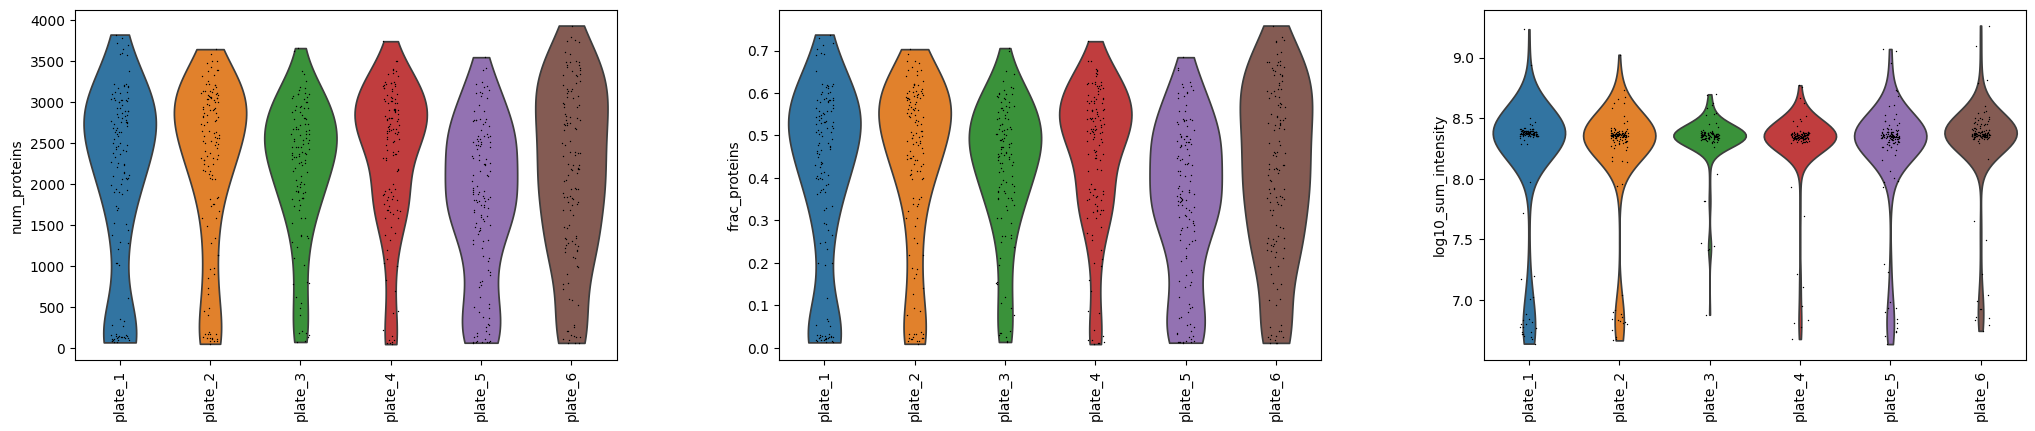

In [ ]:
# Plot QC metrics by TECHNICAL covariate
print(f"QC metrics by {technical} (technical covariate):")
sc.pl.violin(adata, keys=["num_proteins", "frac_proteins", "log10_sum_intensity"], groupby=technical, rotation=90)

QC metrics by zone (biological covariate):


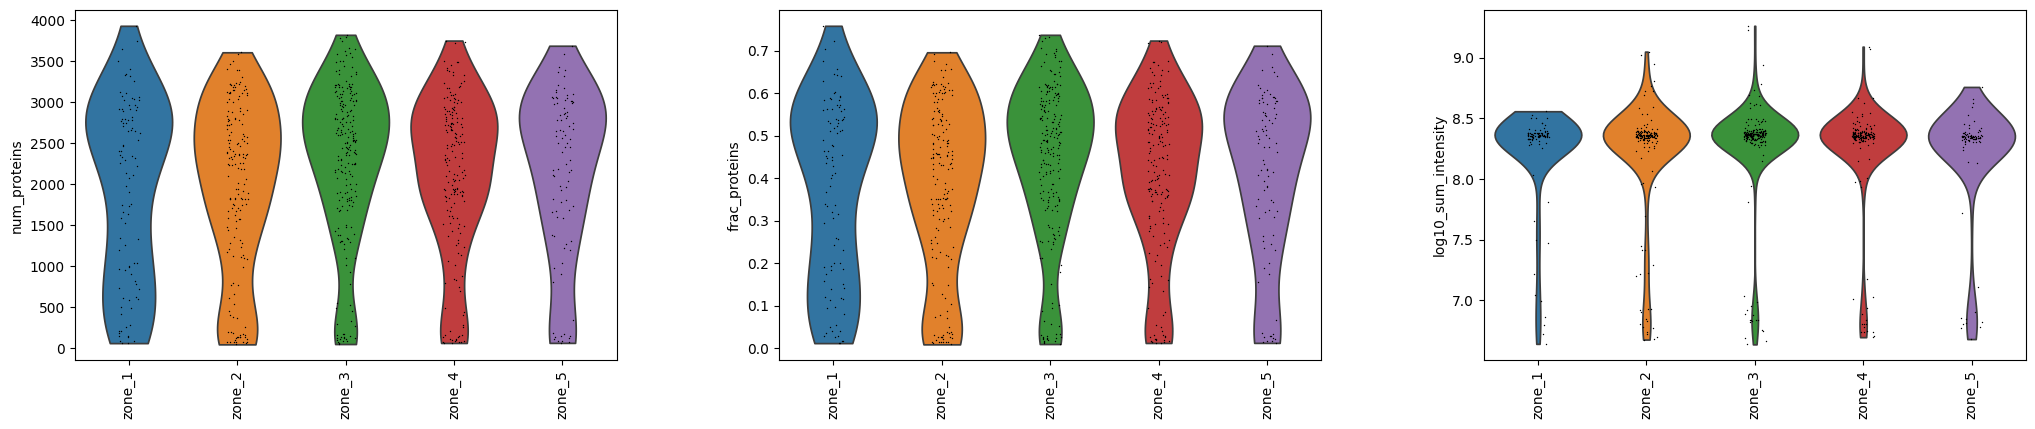

In [ ]:
# Plot QC metrics by BIOLOGICAL covariate
# Differences here could be real biology or confounding with technical factors

print(f"QC metrics by {biological} (biological covariate):")
sc.pl.violin(adata, keys=["num_proteins", "frac_proteins", "log10_sum_intensity"], groupby=biological, rotation=90)

From these plots we can see that the different batches as well as the differnet biological conditions have the same values more or less with similar distributions. all conditions have a "tail" of samples with a lower sum of intensity (1.5 orders of magnitude from median sum, about 30-fold difference) and numbers of proteins. Given these differences, it might be useful to filter out the samples with low sum if intensity.  

## Visualizing QC Metric Relationships

Scatter plots of QC metrics help identify:
1. **Outlier samples**: Points far from the main cluster
2. **Batch effects**: Systematic shifts between technical groups
3. **Expected correlations**: Detection and intensity should correlate positively (depending on the upsteam quantification)

### What to Look For:

- **Tight cluster**: Good sample quality and consistency, no sample deviates greatly from the rest of the distribution (outliers)
- **Samples with low detection but high intensity**: Possible poor quality (few proteins dominating)
- **Separation by color (technical groups)**: Batch effects present

  if na_values:

  if na_values:

  if na_values:

  if na_values:

  plt.tight_layout()



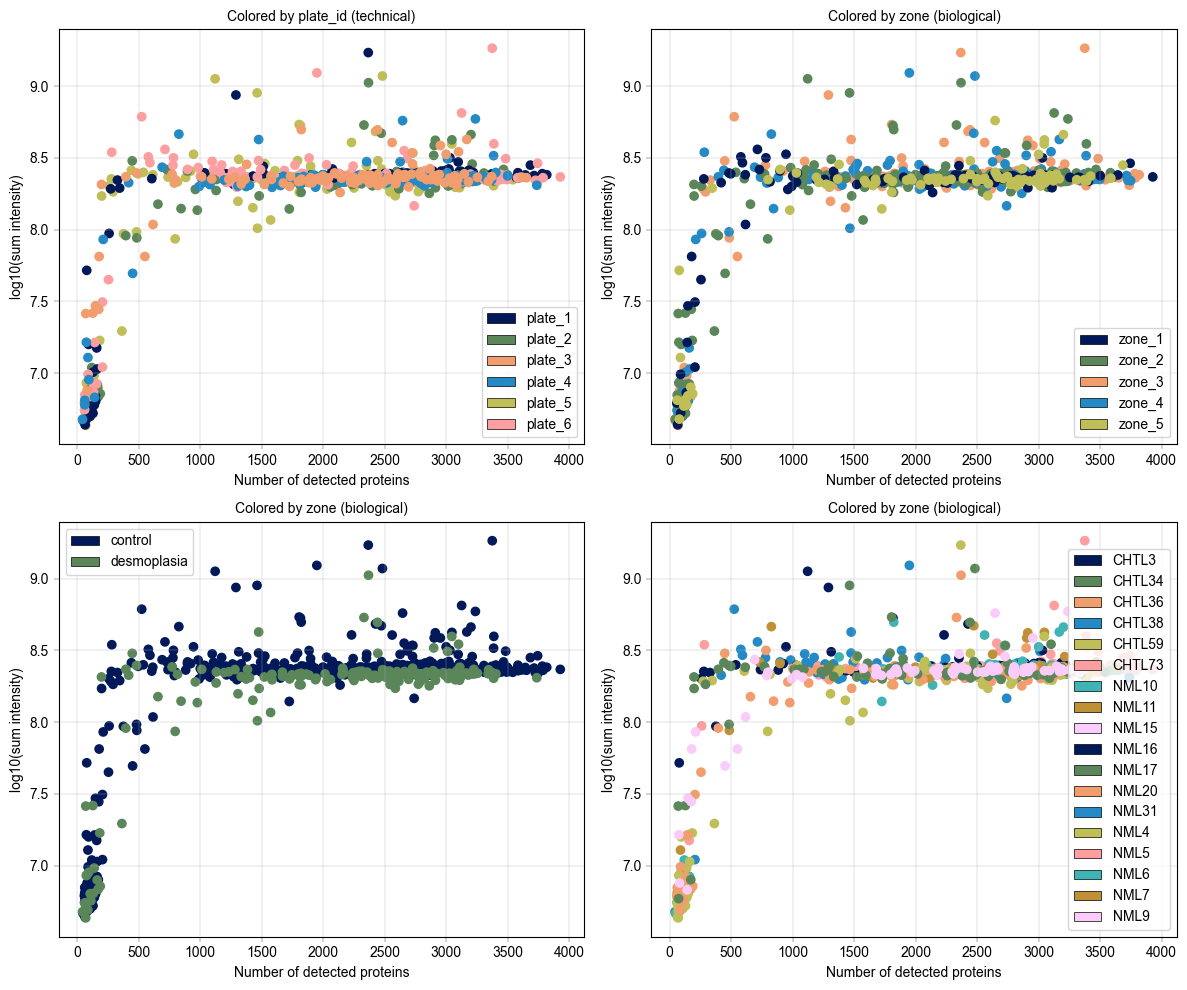

In [ ]:
# Scatter plot: Detection vs Intensity, colored by technical and biological covariates

fig, axm = create_figure(2, 2, figsize=(12, 10))

# By technical covariate
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.obs,
    x_column="num_proteins",
    y_column="log10_sum_intensity",
    color_map_column=technical,
    ax=ax,
    legend="auto",
)
label_axes(
    ax,
    xlabel="Number of detected proteins",
    ylabel="log10(sum intensity)",
    title=f"Colored by {technical} (technical)",
)

# By biological covariate
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.obs,
    x_column="num_proteins",
    y_column="log10_sum_intensity",
    color_map_column=biological,
    ax=ax,
    legend="auto",
)
label_axes(
    ax,
    xlabel="Number of detected proteins",
    ylabel="log10(sum intensity)",
    title=f"Colored by {biological} (biological)",
)

# By condition covariate
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.obs,
    x_column="num_proteins",
    y_column="log10_sum_intensity",
    color_map_column="condition",
    ax=ax,
    legend="auto",
)
label_axes(
    ax,
    xlabel="Number of detected proteins",
    ylabel="log10(sum intensity)",
    title=f"Colored by {biological} (biological)",
)

# By sample covariate
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.obs,
    x_column="num_proteins",
    y_column="log10_sum_intensity",
    color_map_column="donor_id",
    ax=ax,
    legend="auto",
)
label_axes(
    ax,
    xlabel="Number of detected proteins",
    ylabel="log10(sum intensity)",
    title=f"Colored by {biological} (biological)",
)

plt.tight_layout()
plt.show()

In this example, we can again notice the cells deviating from the main cluster. These cells have less than 500 detected proteins and lower than 10^8 sum intensity. After checking for the identity of these cells (mixed conditions, donors, plates and zone), we assume that these are low quality cells rather than an interesting subpopulation or specific batch and can consider filtering them out. 

---

# Missing Value Analysis

## Understanding Missing Values in Proteomics

Missing values in low inpiu DIA data aquisition are considered to be missing not at random (MNAR), meaning that the missingness is (largly) dependent on the abundance level of the protein  - low-abundance proteins are more likely to be missing.

### Why This Matters

- **Don't impute blindly**: Simple imputation (e.g., zeros) can distort biological signal
- **Missing patterns can indicate batch effects**: Different batches may have different detection thresholds
- **Filtering may be necessary**: Proteins with too many missing values are unreliable for statistical testing

We will visualize the completeness (1 - fraction of missing valuse) of the samples 

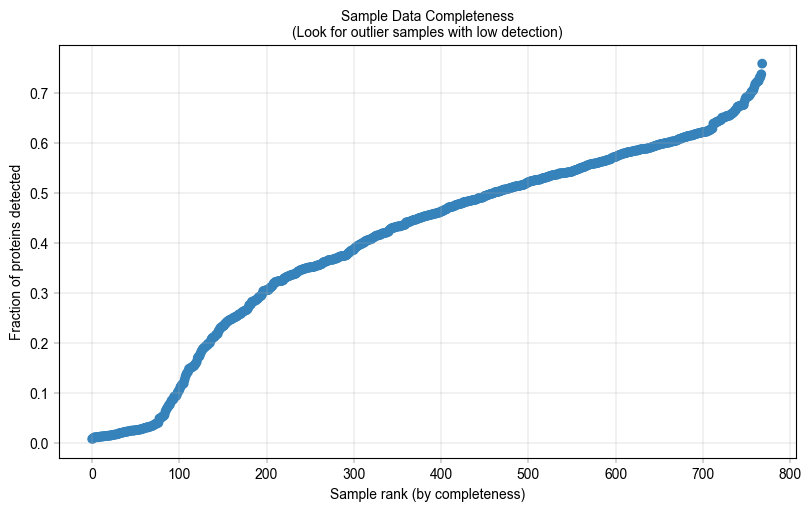

In [ ]:
# Sample completeness: What fraction of proteins does each sample detect?

# Rank samples by completeness
sample_ranks = np.argsort(np.argsort(adata.obs["frac_proteins"]))
adata.obs["sample_rank"] = sample_ranks

fig, axm = create_figure(1, 1, figsize=(8, 5))
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.obs,
    x_column="sample_rank",
    y_column="frac_proteins",
    ax=ax,
)
label_axes(
    ax,
    xlabel="Sample rank (by completeness)",
    ylabel="Fraction of proteins detected",
    title="Sample Data Completeness\n(Look for outlier samples with low detection)",
)
plt.show()

The plot shows that approximately 50% of the cells have around 50% completeness. This may reflect the overall quality of the samples, consistent with the plot showing the number of detected proteins.

These plots help identify **low-quality samples**. We visualize them in multiple ways to ensure that filtering does not unintentionally remove important groups of samples (e.g., specific conditions or batches) and to estimate an appropriate filtering threshold.

## Protein-Level Missing Values

Some proteins are detected in all samples ("core proteome"), while others are detected sporadically. Understanding this distribution helps with:

1. **Filtering decisions**: Should we exclude proteins detected in < X% of samples?
2. **Imputation strategies**: Different approaches for different missingness rates
3. **Statistical testing**: Proteins with many missing values have less statistical power

We will plot the distribution of the **protein** completeness (in what fraction of the cells the protein was detected) to get an overview of the prtoeins.

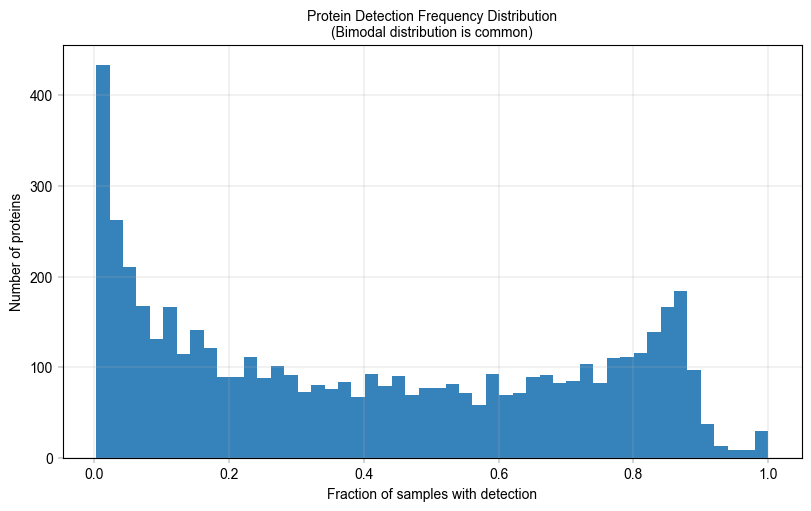

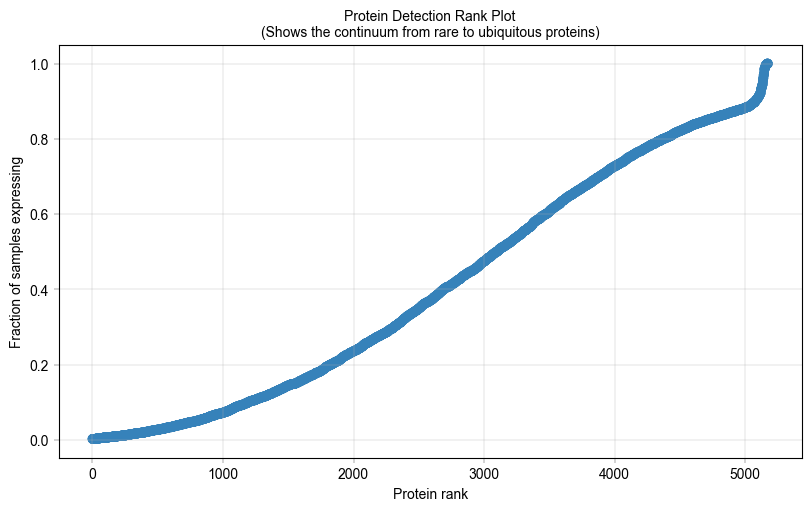

In [ ]:
# Protein detection frequency: In how many samples is each protein detected?

adata.var["num_expressing_samples"] = np.sum(~np.isnan(adata.X), axis=0)
adata.var["frac_expressing_samples"] = adata.var["num_expressing_samples"] / adata.n_obs

# Histogram of detection frequency
fig, axm = create_figure(1, 1, figsize=(8, 5))
ax = axm.next()
at.pl.Plots.histogram(
    data=adata.var,
    value_column="frac_expressing_samples",
    bins=50,
    ax=ax,
)
label_axes(
    ax,
    xlabel="Fraction of samples with detection",
    ylabel="Number of proteins",
    title="Protein Detection Frequency Distribution\n(Bimodal distribution is common)",
)
plt.show()

# Rank plot
protein_ranks = np.argsort(np.argsort(adata.var["frac_expressing_samples"]))
adata.var["protein_rank"] = protein_ranks

fig, axm = create_figure(1, 1, figsize=(8, 5))
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.var,
    x_column="protein_rank",
    y_column="frac_expressing_samples",
    ax=ax,
)
label_axes(
    ax,
    xlabel="Protein rank",
    ylabel="Fraction of samples expressing",
    title="Protein Detection Rank Plot\n(Shows the continuum from rare to ubiquitous proteins)",
)
plt.show()

## Missing Values vs Abundance

This is a **key diagnostic plot** in proteomics QC. It demonstrates that missing values are **not random** - they correlate with protein abundance.
This can help us asses the more "reliable" abundance levels, in which most of the proteins are above detection limit in most of the samples.

**Expected pattern:** Low-abundance proteins have more missing values (MNAR behavior)

**Implications:**
- Statistical tests should account for this systematic missingness
- Consider abundance-aware imputation methods if imputation is necessary

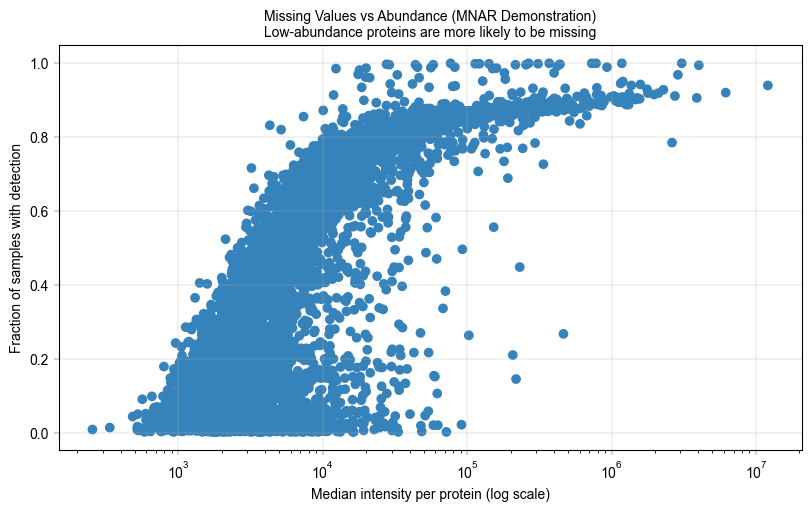

In [ ]:
# Missing fraction vs median intensity per protein
# This plot demonstrates the MNAR (Missing Not At Random) nature of proteomics data

median_intensity_per_protein = np.nanmedian(adata.X, axis=0)
adata.var["median_intensity"] = median_intensity_per_protein

fig, axm = create_figure(1, 1, figsize=(8, 5))
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.var,
    x_column="median_intensity",
    y_column="frac_expressing_samples",
    ax=ax,
)
ax.set_xscale("log")
label_axes(
    ax,
    xlabel="Median intensity per protein (log scale)",
    ylabel="Fraction of samples with detection",
    title="Missing Values vs Abundance (MNAR Demonstration)\nLow-abundance proteins are more likely to be missing",
)
plt.show()

In this section, we examined the distribution of proteins across samples and the relationship between missing values and intensity levels. These plots provide insight into dataset completeness and help guide the selection of thresholds for protein filtering based on completeness.

---

# Intensity Distribution Analysis

## Rank-Abundance Plot

The rank-abundance (or "rank-median") plot shows the dynamic range of protein abundances. Proteins are ranked by their median intensity across samples.

**What it reveals:**
- **Dynamic range**: How many orders of magnitude does protein abundance span?
- **Dominant proteins**: A few highly abundant proteins often dominate the proteome
- **Detection limit**: The "tail" shows the low end of detection

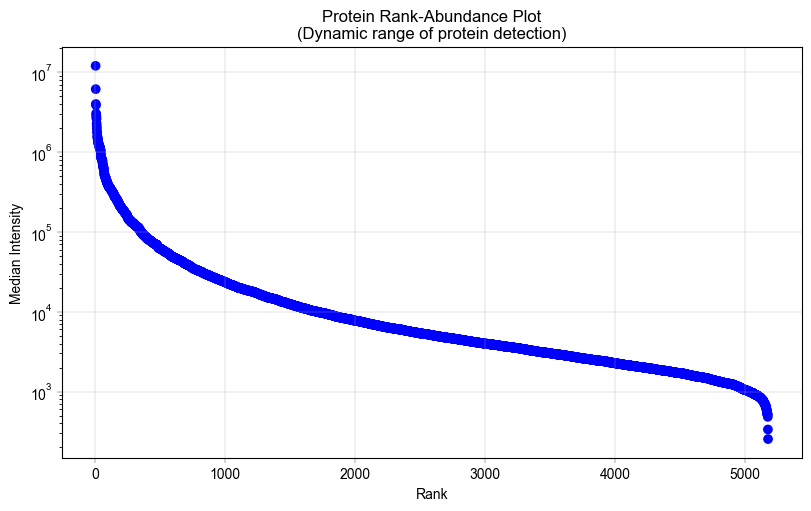

In [ ]:
# Rank-median plot: Shows the dynamic range of protein abundances

fig, axm = create_figure(1, 1, figsize=(8, 5))
ax = axm.next()
at.pl.Plots.rank_median_plot(adata, ax=ax)
plt.title("Protein Rank-Abundance Plot\n(Dynamic range of protein detection)")
plt.show()

## Cumulative Intensity Distribution

This plot shows what fraction of total intensity is contributed by the top N proteins.

**Key insight:** In most proteomics datasets, a small fraction of proteins contributes the majority of the signal. This should be taken into account when considering normalization to the sum or to the median.

**What to look for:**
- **Steep initial rise**: Few proteins dominate the proteome (typical)
- **Similar curves across samples**: Consistent sample preparation
- **Outlier curves**: May indicate sample quality issues

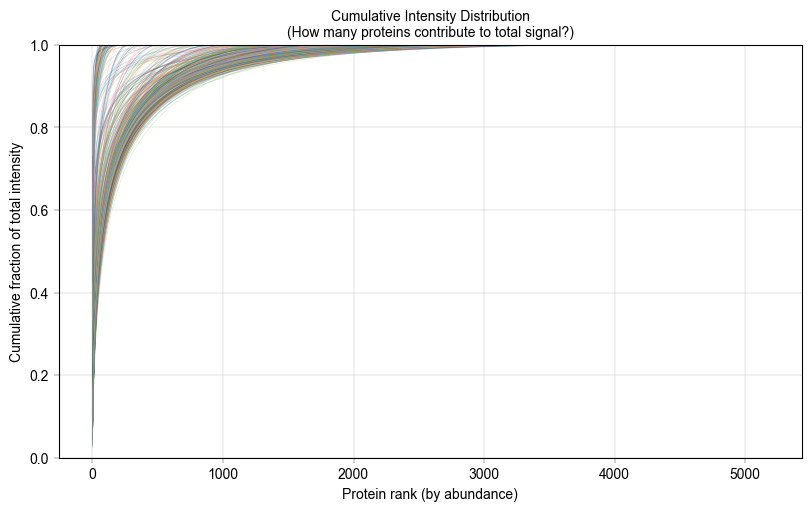

In [ ]:
# Cumulative intensity distribution per sample
# Shows how total signal is distributed across proteins

fig, axm = create_figure(1, 1, figsize=(8, 5))
ax = axm.next()

# Create zero-filled layer for cumulative sum calculation
adata.layers["zero_filled"] = adata.X.copy()
adata.layers["zero_filled"][np.isnan(adata.layers["zero_filled"])] = 0

for i in range(adata.layers["zero_filled"].shape[0]):
    sample_values = adata.layers["zero_filled"][i, :].flatten()
    sorted_values = np.sort(sample_values)[::-1]
    cumsum_values = np.cumsum(sorted_values)
    cumsum_values /= cumsum_values[-1]  # normalize to total intensity (=1)
    ax.plot(cumsum_values, alpha=0.3, linewidth=0.5)

label_axes(
    ax,
    xlabel="Protein rank (by abundance)",
    ylabel="Cumulative fraction of total intensity",
    title="Cumulative Intensity Distribution\n(How many proteins contribute to total signal?)",
)
ax.set_ylim(0, 1)
plt.show()

Here we see that most cells show a steep curve, with 80% of the sum gained about after 200-500 proteins, and some cells shoot up close to 100% of the sum intensity after only a few proteins. These might be poor quality cells.

## Sum intensities of only proteins which account individually for less than 10% of sum intensity 
It is common in transcriptomics to exclude highly expressed genes from normaliztion calculations. By taking them out, we can observe if there are differences in the sum untensities of the rest of the proteins in the samples (otherwise obscured by the high level proteins)

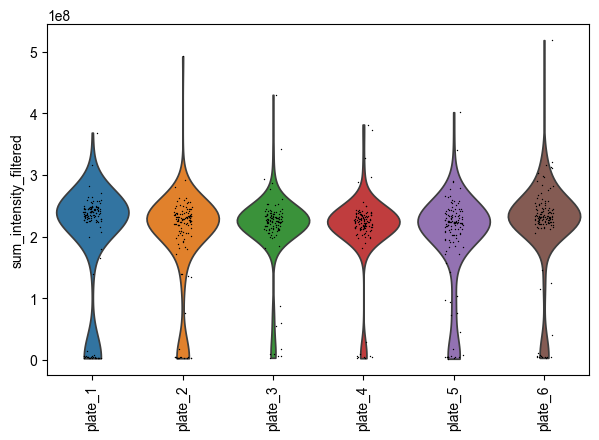

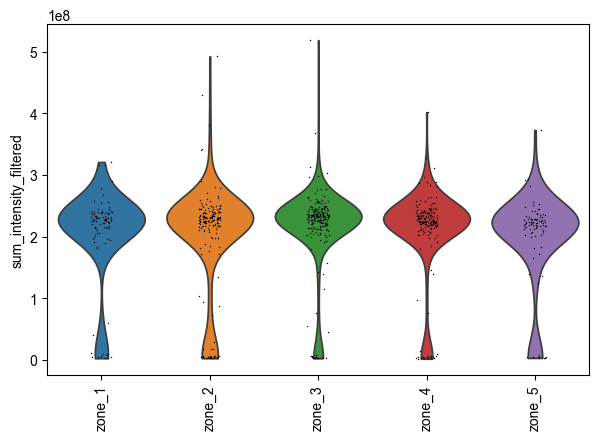

  if na_values:

  plt.tight_layout()



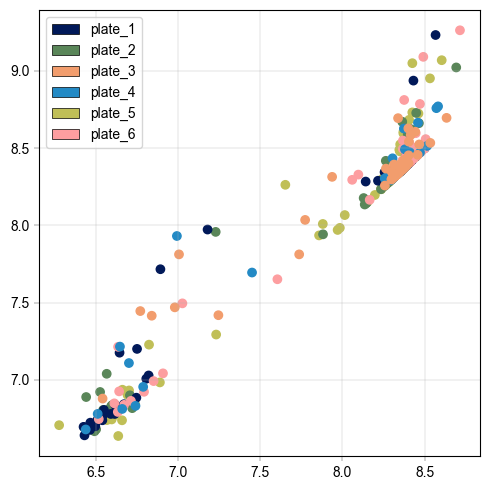

In [ ]:
# Calculate sum intensity per sample, excluding genes > 20% of total
def sum_excluding_dominant(row: np.ndarray, pc: float) -> float:
    """
    Calculate sum intensity excluding dominant proteins.

    Sums only proteins that contribute less than 10% of total intensity,
    useful for detecting quality differences obscured by highly abundant proteins.
    Args:
        row: Array of protein intensities for a sample
        pc: Proportion cutoff to define dominant proteins
    Returns:
        Sum of intensities for non-dominant proteins
    """
    total = np.nansum(row)
    if total == 0 or np.isnan(total):
        return 0.0
    # Keep only genes contributing < 10% of total
    fractions = row / total
    mask = fractions < pc
    return float(np.nansum(row[mask]))


# Apply to each sample (row)
adata.obs["sum_intensity_filtered"] = np.apply_along_axis(sum_excluding_dominant, axis=1, arr=adata.X, pc=0.1)

adata.obs["log_sum_intensity_filtered"] = np.log10(adata.obs["sum_intensity_filtered"])


sc.pl.violin(adata, keys=["sum_intensity_filtered"], groupby=technical, rotation=90)
sc.pl.violin(adata, keys=["sum_intensity_filtered"], groupby=biological, rotation=90)

fig, axm = create_figure(1, 1, figsize=(5, 5))
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.obs,
    x_column="log_sum_intensity_filtered",
    y_column="log10_sum_intensity",
    color_map_column=technical,
    ax=ax,
    legend="auto",
)
plt.tight_layout()
plt.show()

These plots illustrate the variability between proteins in the dataset, spanning several orders of magnitude. The fact that a small number of proteins account for the majority of the total sample intensity is not observed in RNA sequencing, which may partly explain why standard normalization methods used in RNA-seq are often not suitable for mass spectrometry data.

---

# Coefficient of Variation (CV) Analysis

## What is CV?

The **Coefficient of Variation** measures relative variability:

$$CV = \frac{\text{Standard Deviation}}{\text{Mean}} \times 100\%$$

## Why CV Matters in Proteomics

- **Reproducibility metric**: Lower CV = more reproducible measurements
- **Technical vs biological variation**: Technical replicates should have CV < 20%
- **Protein reliability**: High-CV proteins between replicates may be unreliable for biological interpretation and can be statistically challenging.

## Guidelines from the Literature

| CV Range | Interpretation |
|----------|----------------|
| < 10% | Excellent reproducibility |
| 10-30% | Good, typical for biological replicates |
| 30-50% | Acceptable for some applications |
| > 50% | High variability, interpret with caution |

## CV vs Abundance

Low-abundance proteins typically have higher CV due to:
- Measurement noise is larger relative to signal
- Stochastic sampling effects
- Near-detection-limit variability


In [ ]:
# Calculate CV for each protein
at.metrics.coefficient_of_variation(adata, key_added="CV", min_valid=3)

  plt.tight_layout()



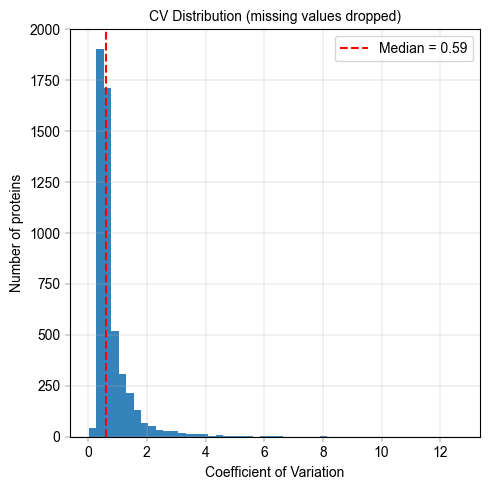

In [ ]:
# CV distribution histogram

fig, axm = create_figure(1, 1, figsize=(5, 5))

ax = axm.next()
at.pl.Plots.histogram(
    data=adata.var,
    value_column="CV",
    bins=50,
    ax=ax,
)
# Add median line
median_cv = adata.var["CV"].median()
ax.axvline(median_cv, color="red", linestyle="--", label=f"Median = {median_cv:.2f}")

ax.legend()
label_axes(
    ax,
    xlabel="Coefficient of Variation",
    ylabel="Number of proteins",
    title="CV Distribution (missing values dropped)",
)


plt.tight_layout()
plt.show()

Here see relatively high CVs, as we are pooling all cells in the datasets, and not just "replicates". So the high CV is expected. 


---

# Coefficient of Variation (CV) vs the mean 

We saw that the CV is used to assess reproducibility and stability of the data when chacked **across replicates**. 
Between different biological/experimetal groups, high CV can indicate that these proteins are differentially expressed. 
Also, highly variable proteins are the main drivers of many downstream analyses (such as PCA and clustering). Therefore, it is useful to check the protein variabilty. To do so, we can plot the CV against the mean abundance. We can expect a negative correlation (high CV - lower mean), and all the proteins that fall above that line are highly variable ones. 
Since NaN values should not be dropped in this analysis (dispersion also depends on the number of samples), we will assign minimal value to NaNs and calculate the CV and mean on that.  

**What it can help us with:**
 - compare those proteins with our biological assumptions/expectations from the dataset 
 - identify potential highly variable contaminants
 - estimate abundance levels of technical noise




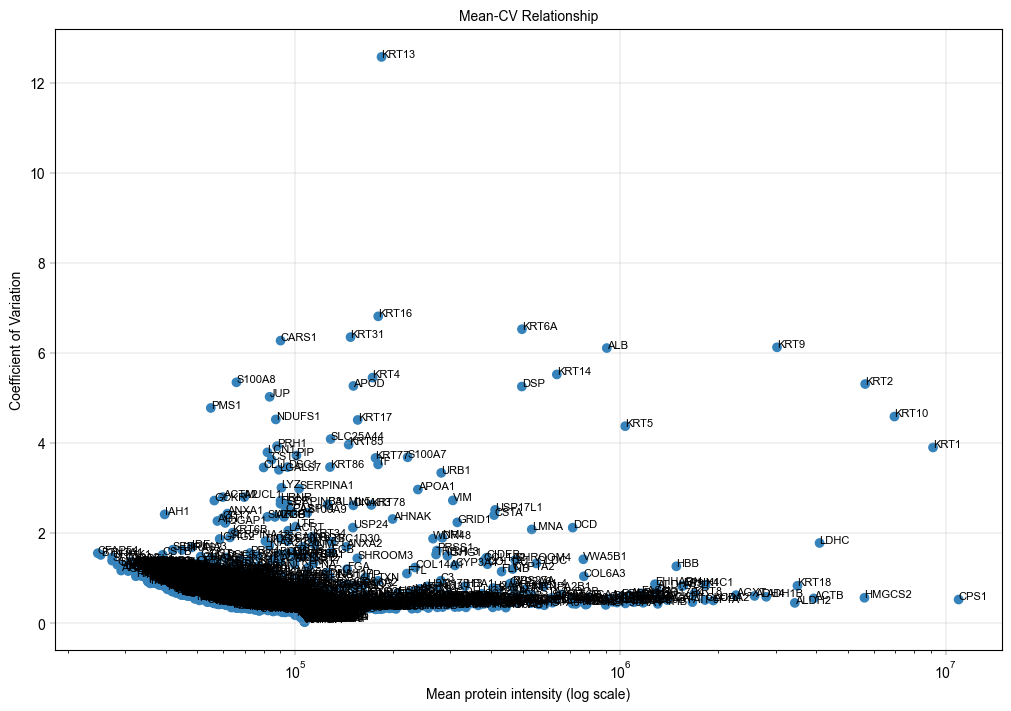

In [ ]:
# Mean-CV relationship (classic proteomics QC plot)
MIN = np.nanmean(adata.X)
adata.layers["orig_intensity"] = adata.X.copy()
adata.X[np.isnan(adata.X)] = MIN
# calculate CV again with imputed missing values
at.metrics.coefficient_of_variation(adata, key_added="CV_imp", min_valid=3)
# calculate mean again with imputed missing values
adata.var["protein_mean_imp"] = np.nanmean(adata.X, axis=0)

# get back to original X for future plots
adata.X = adata.layers["orig_intensity"].copy()

fig, axm = create_figure(1, 1, figsize=(10, 7))
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.var,
    x_column="protein_mean_imp",
    y_column="CV_imp",
    ax=ax,
)
ax.set_xscale("log")

# for visualization, get first gene name if multiple are present
adata.var["single_gene_name"] = adata.var["Genes"].str.split(";").str[0].copy()

# Add protein labels for extreme outliers
at.pl.label_plot(
    ax=ax,
    x_values=adata.var["protein_mean_imp"],
    y_values=adata.var["CV_imp"],
    labels=adata.var["single_gene_name"],
    # use small font size for better readability
    label_kwargs={"fontsize": 8},
)


label_axes(
    ax, xlabel="Mean protein intensity (log scale)", ylabel="Coefficient of Variation", title="Mean-CV Relationship"
)
plt.show()

This plot highlights the highly variable proteins (HVPs) in the dataset. In this example, Keratins (KRT) appear among the HVPs. Since these are known contaminants, they can be considered for removal in downstream analyses, particularly PCA, because we are not interested in variability driven by contamination.

---

# Sanity check using individual Protein

## Checking Known Markers

If you have **known biological markers** or **expected patterns**, checking their distributions is a good and fast way to test how well the data meet the biological expections from existing knowledge.

**For liver peotein zonation data, we expect:**
- **CYP2E1, GLUL**: Central zone markers, should be higher in zone 5 and gradually decreasing.
- **CPS1, ASS1**: Periportal markers, should be higher in zone 1 and gradually decreasing.
**What to check:**
1. Do known markers show expected biological patterns?
2. Are distributions similar across technical batches (after accounting for biology)?

... storing 'single_gene_name' as categorical


[<Axes: ylabel='P31327'>, <Axes: ylabel='P00966'>]

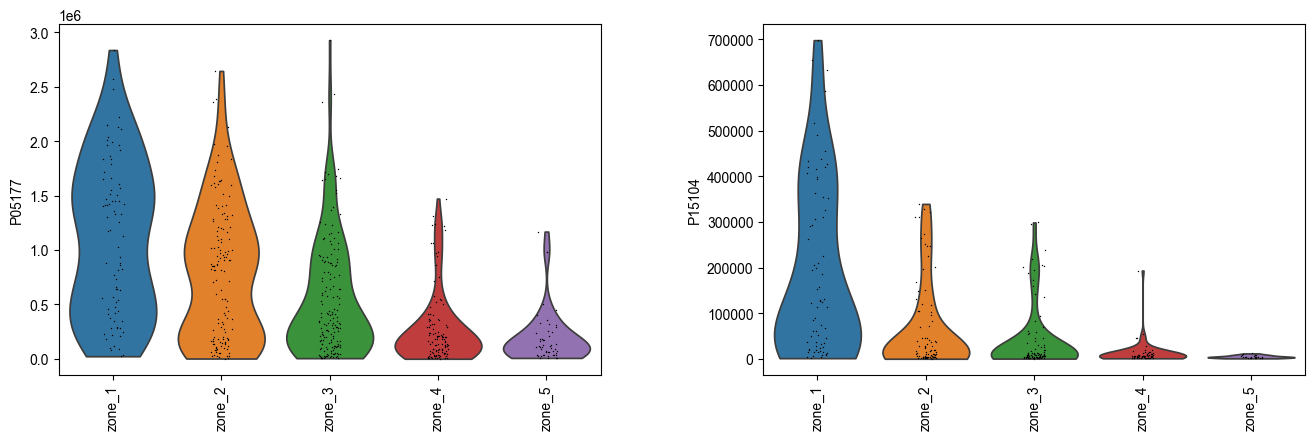

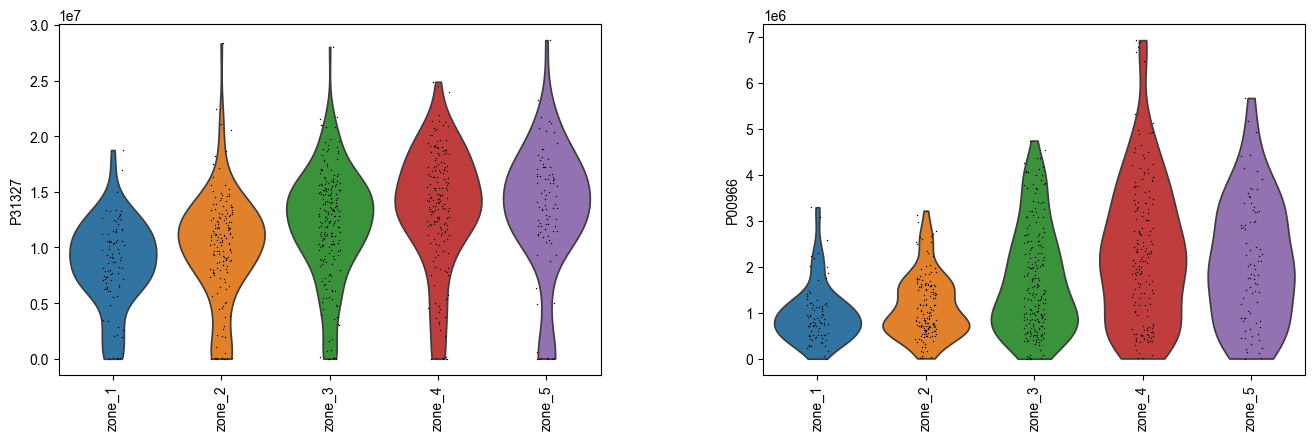

In [ ]:
# Check distribution of known marker proteins

pericentral = ["P05177", "P15104"]  # CYP1A2, CYP2E1
periportal = ["P31327", "P00966"]  # CPS1, ASS1

sc.pl.violin(adata, keys=pericentral, groupby=biological, rotation=90, show=False)
sc.pl.violin(adata, keys=periportal, groupby=biological, rotation=90, show=False)

for this example we could observe the expected patterns, even for non filtered dataset. Of course, this also dependes on the magnitude of the expected patterns. When the expected patterns are not observed, this could indicate that a filtering might be needed, or that there is a variability source (e.g. inter-individual) that should be accounted for in downstream analyses.

---

# Data Filtering

## Filtering Philosophy
Filtering involves a trade-off between losing data points and removing technical noise, both of which can affect downstream statistical analyses. Typically, the filtering threshold is set based on the QC plots and the experimental design (e.g., number of samples) and overall data quality. But how stringent should the thresholds be? In their scRNA-seq tutorial, Luecken and Theis (2019) recommend an iterative approach: start with a permissive threshold and adjust it downward if downstream analyses reveal technical artifacts. This strategy is also appropriate in the current context. 

### Sample Filtering
Following the manuscript methodology:
- Remove samples with very low protein detection
- Remove outliers identified in QC plots
- Ensure each condition/zone has sufficient representation

### Why Filter?
- **Statistical power**: Sparse data reduces ability to detect real differences
- **Noise reduction**: Sporadic detections add noise without biological meaning


For sample filtering, we will follow the manuscript, where Z scores of the number of proteins detected per sample were used to label outliers as samples with less than 1.5 standard deviations from the mean or above 3 standard deviations from the mean across samples.
We will introduce a small change, and use MAD (median absolute deviation) to calculate a non parametric equivalent of Z-score, which is considered to be more robust, as suggested by the authors of "Best practices for single-cell analysis across modalities". We will then filter out samples above and below 3 MAD from the median. 
Plotting and coloring by the label would help us assess if we set right threshold.  


  if na_values:



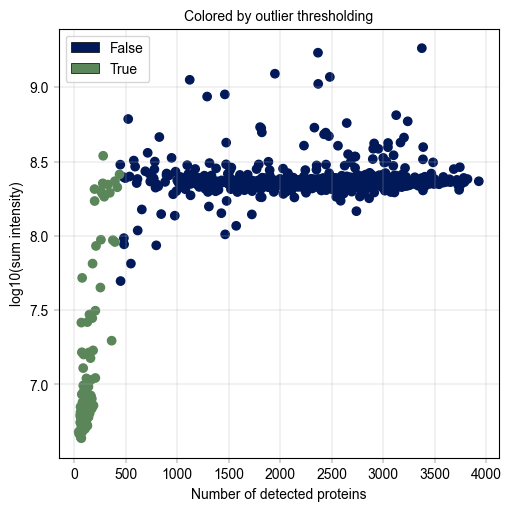

In [ ]:
median_proteins = np.median(adata.obs["num_proteins"])
mad_proteins = np.median(np.abs(adata.obs["num_proteins"] - median_proteins))
adata.obs["num_proteins_MAD"] = (adata.obs["num_proteins"] - median_proteins) / mad_proteins

# mark outliers
LOW = -3
HIGH = 3
adata.obs["is_outlier"] = (adata.obs["num_proteins_MAD"] < LOW) | (adata.obs["num_proteins_MAD"] > HIGH)
# plot to see that these are indeed outliers
fig, axm = create_figure(1, 1, figsize=(5, 5))

ax = axm.next()
at.pl.Plots.scatter(
    data=adata.obs,
    x_column="num_proteins",
    y_column="log10_sum_intensity",
    color_map_column="is_outlier",
    ax=ax,
    legend="auto",
)
label_axes(
    ax,
    xlabel="Number of detected proteins",
    ylabel="log10(sum intensity)",
    title="Colored by outlier thresholding",
)

Now that we've seen that the outlier filter is adequate, we will filter out the outliers. 
Like the study, we will focus our analysis on the control cohort, so will keep only samples from this condition.

For the first filtering step, we will create a copy of the filtered adata, to keep a version of the full dataset, in case we would like to go back and apply different filtering thresholds. 

In [ ]:
# filter out the outlier samples (number of detected proteins should be independent of condition, therefore we apply a single threshold here)
adata_filtered = adata[~adata.obs["is_outlier"], :].copy()
adata_filtered = adata_filtered[adata_filtered.obs["condition"] == "control", :]

print(f"Remaining samples before outlier removal: {adata.n_obs}")
print(f"Remaining samples after outlier removal: {adata_filtered.n_obs}")

Remaining samples before outlier removal: 769
Remaining samples after outlier removal: 531


## Protein Filtering

Following the manuscript: "...an additional filtering criterion at the protein level was applied, requiring proteins to be detected in at least 70% of samples..." - we will apply the same threshold here.
Based on the QC plots, this threshold would remove more than 50% of the proteins. Alternative approaches include using less stringent thresholds and iteratively adjust according to downstream evaluations, or applying imputation. Even when imputation is used, it is still recommended to remove proteins with very low coverage.

**Why this threshold?**
- Reduces noise from sporadic detections
- Creates a reliable "proteome" for downstream analyses



  adata.var[var_colname] = ~drop_mask

INFO:root:pp.filter_data_completeness(): flag 3519 / 5175 features with >0.30 missing in any group.
  if na_values:



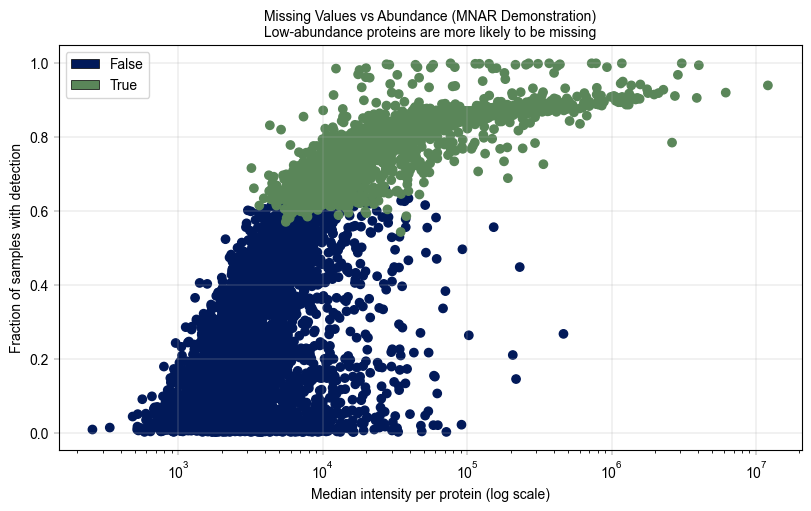

In [ ]:
adata_filtered = at.pp.filter_data_completeness(
    adata_filtered, max_missing=0.3, action="flag", var_colname="completeness_filter"
)
ig, axm = create_figure(1, 1, figsize=(8, 5))
ax = axm.next()
at.pl.Plots.scatter(
    data=adata_filtered.var,
    x_column="median_intensity",
    y_column="frac_expressing_samples",
    color_map_column="completeness_filter",
    legend="auto",
    ax=ax,
)
ax.set_xscale("log")
label_axes(
    ax,
    xlabel="Median intensity per protein (log scale)",
    ylabel="Fraction of samples with detection",
    title="Missing Values vs Abundance (MNAR Demonstration)\nLow-abundance proteins are more likely to be missing",
)

In [ ]:
# now we filter the proteins to keep only those detected in 70% of samples

adata_filtered = at.pp.filter_data_completeness(adata_filtered, max_missing=0.3, action="drop")
print(f"Remaining proteins after filtering for 70% completeness: {adata_filtered.n_vars}")

INFO:root:pp.filter_data_completeness(): drop 3519 / 5175 features with >0.30 missing in any group.


Remaining proteins after filtering for 70% completeness: 1656


---

# Dimensionality Reduction & Variance Analysis

## PCA in Proteomics: What to Expect

PCA reveals the **major sources of variance** in your data. In a well-designed experiment:
- **Ideal**: Samples cluster by biological condition (zonation)
- **Problematic**: Samples cluster by technical factor (donor, plate)

## Interpreting PCA Results

### What Good Results Look Like
- Samples from same biological group cluster together
- Technical replicates are closer to each other than to other samples.

### Warning Signs
- Samples cluster by batch/donor instead of biology
- Single outlier samples far from main cluster
- No clear structure (random scatter)

### Expected Zonation Pattern
For liver data, we expect a zonation gradient along the first PCs (usually apparent on PC1)
If PCA separates zones → biological signal preserved.

## Core Proteome for PCA

For PCA, we use only **completely detected proteins** (no missing values). 

## Contaminant flagging
As we saw in preveous figures, common proteomics contaminants are highly variable in the dataset:
- **Keratins (KRT*)**: Skin contamination from sample handling
- **Serum albumin (ALB)**: Often dominates signal, may mask other proteins
- **Hemoglobin (HB*) and immunoglobulins**: Blood contamination

We further exclude these from PCA (even if they are present in the "core proteome") but keep them for total intensity calculations, as we are not interested in their variability.


In [ ]:
# Define core proteome: proteins detected in all samples, excluding contaminants

# Flag proteins with no missing values
adata_filtered = at.pp.filter_data_completeness(adata_filtered, max_missing=0, action="flag", var_colname="is_core")

# we will also remove the contaminants  from the PCA, as it may be a contamination
adata_filtered.var["prot_for_pca"] = (
    adata_filtered.var["is_core"]
    & ~(adata_filtered.var["Genes"].str.startswith("KRT", na=False))
    & ~(adata_filtered.var["Genes"].str.startswith("ALB", na=False))
    & ~(adata_filtered.var["Genes"].str.startswith("DSP", na=False))  # skin protein contaminant
    & ~(adata_filtered.var["Genes"].str.startswith("IGG", na=False))
)


print(f"{adata_filtered.var['prot_for_pca'].sum()} proteins")
print("  detected in all samples, excluding contaminants")

INFO:root:pp.filter_data_completeness(): flag 1618 / 1656 features with >0.00 missing in any group.


30 proteins
  detected in all samples, excluding contaminants


In [ ]:
# Run PCA on core proteome

at.tl.pca(adata_filtered, meta_data_mask_column_name="prot_for_pca")

INFO:alphapepttools.tl.embeddings:computing PCA


AnnData object with n_obs × n_vars = 531 × 1656
    obs: 'id', 'score', 'donor_id', 'plate_id', 'condition', 'zone', 'num_proteins', 'frac_proteins', 'sum_intensity', 'log10_sum_intensity', 'sample_rank', 'sum_intensity_filtered', 'log_sum_intensity_filtered', 'num_proteins_MAD', 'is_outlier'
    var: 'Protein.Group', 'Protein.Names', 'Genes', 'num_expressing_samples', 'frac_expressing_samples', 'protein_rank', 'median_intensity', 'CV', 'CV_imp', 'protein_mean_imp', 'single_gene_name', 'completeness_filter', 'is_core', 'prot_for_pca'
    uns: 'plate_id_colors', 'zone_colors', 'variance_pca_obs'
    obsm: 'X_pca_obs'
    varm: 'PCs_obs'
    layers: 'zero_filled', 'orig_intensity'

INFO:root:Column 'zone' found in: data.obs.columns. Using that
INFO:root:Column 'zone' found in: data.obs.columns. Using that
  if na_values:

INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that
INFO:root:Column 'plate_id' found in: data.obs.columns. Using that
INFO:root:Column 'plate_id' found in: data.obs.columns. Using that
  if na_values:

INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that


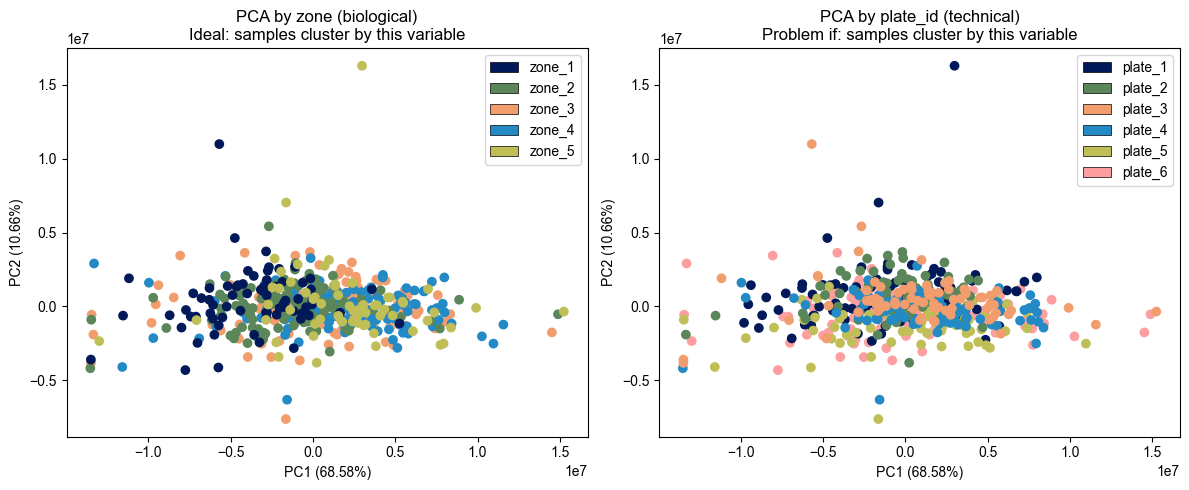

In [ ]:
# PCA colored by biological and technical covariates

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# By biological covariate
at.pl.Plots.plot_pca(
    data=adata_filtered, ax=axes[0], x_column=1, y_column=2, label=False, color_map_column=biological, legend="auto"
)
axes[0].set_title(f"PCA by {biological} (biological)\nIdeal: samples cluster by this variable")

# By technical covariate
at.pl.Plots.plot_pca(
    data=adata_filtered, ax=axes[1], x_column=1, y_column=2, label=False, color_map_column=technical, legend="auto"
)
axes[1].set_title(f"PCA by {technical} (technical)\nProblem if: samples cluster by this variable")

plt.tight_layout()
plt.show()

We do see some association between PC1 and zonation, which is as we expected. It is important to note that this PCA is performed on only 63 core proteins (minus contaminants). Much of the dataset variability is not captured by this PCA. However, it is still usefull to plot and understand the PCA for QC. 

## Scree Plot: Understanding Variance Structure

The scree plot shows how much variance each principal component explains.

**Interpretation:**
- **Steep drop after PC1**: One dominant source of variation (could be batch effect!)
- **Gradual decline**: Multiple sources of variation contributing
- **Elbow point**: Rough guide for how many PCs capture meaningful signal

**What to look for:**
- If PC1 explains >30-40% variance, investigate what's driving it
- Compare variance explained with number of conditions in your data

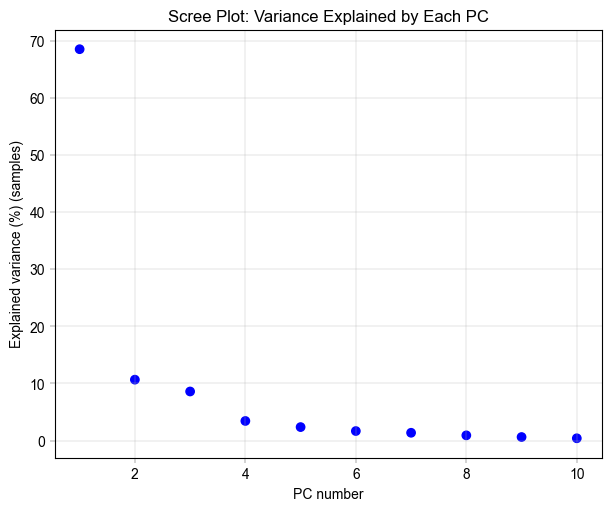

In [ ]:
# Scree plot: variance explained by each PC

fig, axm = create_figure(1, 1, figsize=(6, 5))
ax = axm.next()
at.pl.Plots.scree_plot(adata=adata_filtered, ax=ax, n_pcs=10)
plt.title("Scree Plot: Variance Explained by Each PC")
plt.show()

## PCA Loadings: What Drives Each PC?

Loadings show which proteins contribute most to each principal component. Can help with diagnosing technical noise in the data. 


  plt.tight_layout()



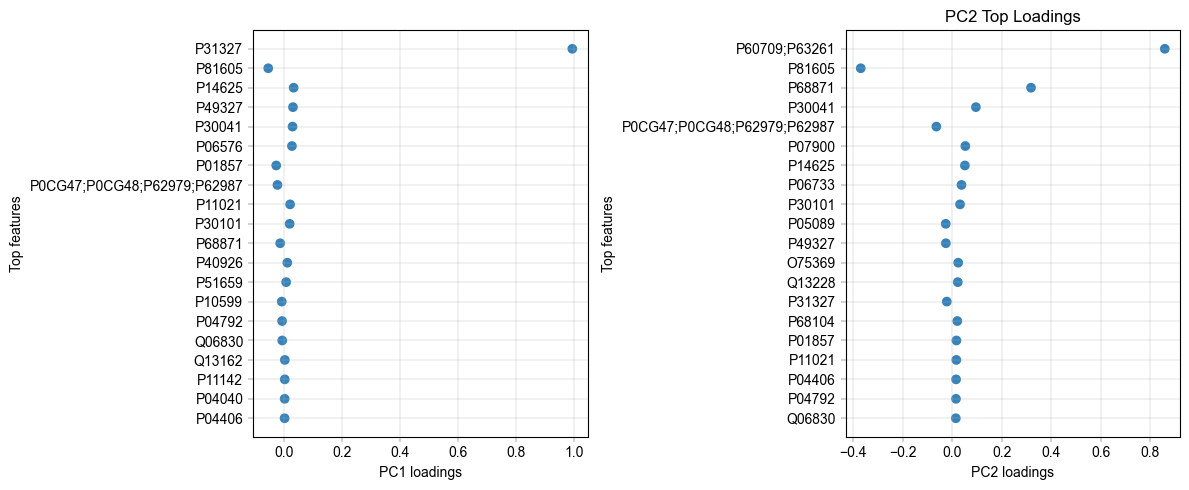

In [ ]:
# Top loadings for PC1

fig, axm = create_figure(1, 2, figsize=(12, 5))

ax = axm.next()
at.pl.Plots.plot_pca_loadings(
    data=adata_filtered,
    ax=ax,
    dim=1,
    nfeatures=20,
)
plt.title("PC1 Top Loadings\n(What proteins drive the main axis of variation?)")

ax = axm.next()
at.pl.Plots.plot_pca_loadings(
    data=adata_filtered,
    ax=ax,
    dim=2,
    nfeatures=20,
)
plt.title("PC2 Top Loadings")

plt.tight_layout()
plt.show()

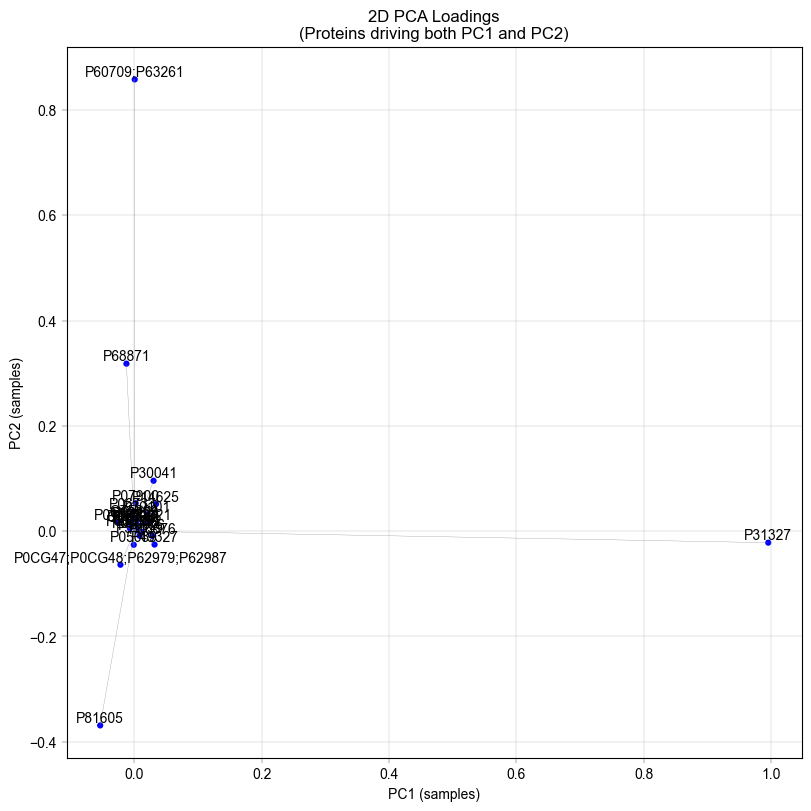

In [ ]:
# 2D loadings plot

fig, axm = create_figure(1, 1, figsize=(8, 8))
ax = axm.next()
at.pl.Plots.plot_pca_loadings_2d(
    data=adata_filtered,
    ax=ax,
    pc_x=1,
    pc_y=2,
    nfeatures=20,
    add_labels=True,
    add_lines=True,
)
plt.title("2D PCA Loadings\n(Proteins driving both PC1 and PC2)")
plt.show()

In [ ]:
# Print top absolute loadings for PC1

loadings = adata_filtered.varm["PCs_obs"]
pc1_loadings = loadings[:, 0]

pc1_loadings_df = pd.DataFrame(
    {
        "protein": adata_filtered.var_names,
        "loading": pc1_loadings,
        "abs_loading": np.abs(pc1_loadings),
        "genes": adata_filtered.var["Genes"],
    }
)
pc1_loadings_df = pc1_loadings_df.dropna().sort_values(by="abs_loading", ascending=False)

print("Top 10 proteins driving PC1 (by absolute loading):")
print(pc1_loadings_df.head(10).to_string(index=False))

Top 10 proteins driving PC1 (by absolute loading):
                    protein   loading  abs_loading                genes
                     P31327  0.995329     0.995329                 CPS1
                     P81605 -0.053720     0.053720                  DCD
                     P14625  0.033991     0.033991              HSP90B1
                     P49327  0.031620     0.031620                 FASN
                     P30041  0.030082     0.030082                PRDX6
                     P06576  0.028071     0.028071              ATP5F1B
                     P01857 -0.026143     0.026143                IGHG1
P0CG47;P0CG48;P62979;P62987 -0.021916     0.021916 RPS27A;UBA52;UBB;UBC
                     P11021  0.021735     0.021735                HSPA5
                     P30101  0.020224     0.020224                PDIA3


## PCA Colored by QC Metrics

Coloring PCA by QC metrics can reveal if technical factors are driving the main axes of variation.

INFO:root:Column 'num_proteins' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that
INFO:root:Column 'log10_sum_intensity' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that
INFO:root:Column 'P05177' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that
INFO:root:Column 'P00966' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that


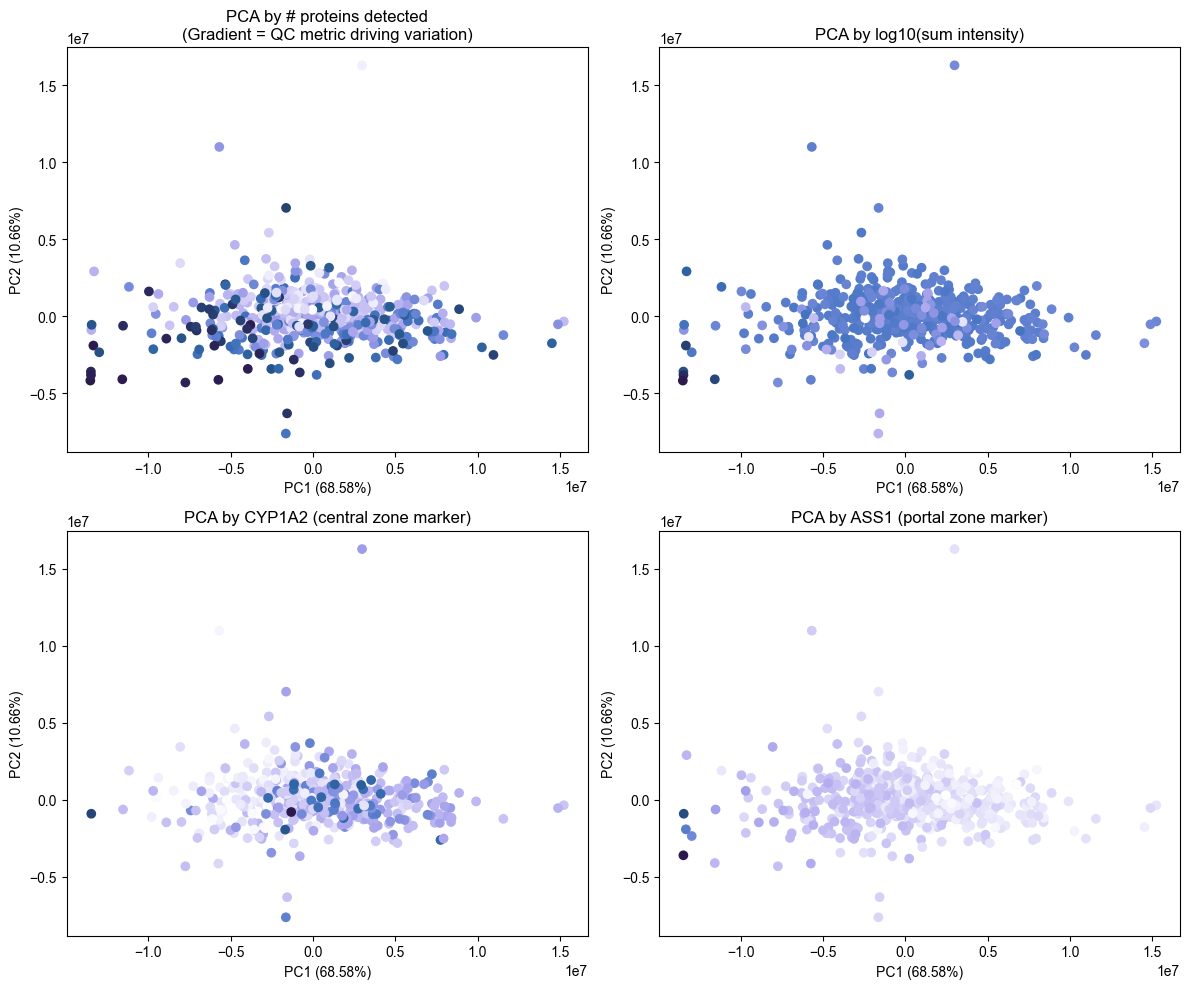

In [ ]:
# PCA colored by QC metrics

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Number of proteins detected
at.pl.Plots.plot_pca(
    data=adata_filtered,
    ax=axes[0, 0],
    x_column=1,
    y_column=2,
    label=False,
    color_map_column="num_proteins",
    palette=BaseColormaps.get("sequential"),
)
axes[0, 0].set_title("PCA by # proteins detected\n(Gradient = QC metric driving variation)")

# Sum intensity
at.pl.Plots.plot_pca(
    data=adata_filtered,
    ax=axes[0, 1],
    x_column=1,
    y_column=2,
    label=False,
    color_map_column="log10_sum_intensity",
    palette=BaseColormaps.get("sequential"),
)
axes[0, 1].set_title("PCA by log10(sum intensity)")

# Known marker: CYP1A2 (central zone)
prot = "P05177"
at.pl.Plots.plot_pca(
    data=adata_filtered,
    ax=axes[1, 0],
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=prot,
    palette=BaseColormaps.get("sequential"),
)
axes[1, 0].set_title("PCA by CYP1A2 (central zone marker)")

# Known marker: ASS1 (portal zone)
prot = "P00966"
at.pl.Plots.plot_pca(
    data=adata_filtered,
    ax=axes[1, 1],
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=prot,
    palette=BaseColormaps.get("sequential"),
)
axes[1, 1].set_title("PCA by ASS1 (portal zone marker)")

plt.tight_layout()
plt.show()

The PCA plots show that PC1 correlates with zonation and known zonated genes, indicating that even when performed using only a few dozen proteins, PCA still captures the spatial variability of hepatocytes.

---

# Recreating Study Figures: Zonation Heatmap (Figure 2B)

## The Zonation Heatmap

This visualization shows protein expression patterns across the portal-central axis, revealing which proteins are enriched in different liver zones.

### Construction Method
1. **Z-score normalization per donor**: Removes donor-specific baseline differences
2. **Bin samples by zonation score**: Group into discrete zones (the study used 20 bins from portal to central, we will use 5)
3. **Average Z-scores per bin**: Creates smooth gradient across zones
4. **Sort proteins by peak position**: Orders proteins by where they're most expressed

### Biological Interpretation

| Pattern | Meaning | Example Proteins |
|---------|---------|-----------------|
| High in bin 1 (portal) | Periportal-enriched | CPS1, ASS1, PCK1 |
| High in bin 20 (central) | Pericentral-enriched | GLUL, CYP2E1, CYP1A2 |
| Flat across bins | Non-zonated (housekeeping) | GAPDH, Actins |


In [ ]:
from scipy.stats import zscore

# Convert adata.X to DataFrame (cells x proteins)
expr_df = pd.DataFrame(
    adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X, index=adata.obs_names, columns=adata.var_names
)

# List to collect per-donor binned means
binned_means_list = []

# Iterate over donors
for _donor, donor_cells in adata.obs.groupby("donor_id"):
    # Select expression for this donor
    donor_expr = expr_df.loc[donor_cells.index]
    # Calculate z-score per protein, ignoring NaNs
    donor_z = donor_expr.apply(lambda x: zscore(x, nan_policy="omit"), axis=0, result_type="broadcast")
    # Bin cells into 5 bins based on 'score'
    bins = pd.qcut(donor_cells["score"], q=5, labels=False) + 1  # bins 1-5
    donor_z["bin"] = bins
    # Calculate mean z-score per protein per bin, ignoring NaNs
    mean_per_bin = donor_z.groupby("bin").mean().T  # proteins as rows
    binned_means_list.append(mean_per_bin)

# Combine all donors: take mean across donors, ignoring NaNs
zone_z_means = pd.concat(binned_means_list, axis=0).groupby(level=0).mean()

  for donor, donor_cells in adata.obs.groupby("donor_id"):



Now plot the heatmap:

  max_bin = zone_z_means.idxmax(axis=1)  # returns the column (bin) of max value per protein



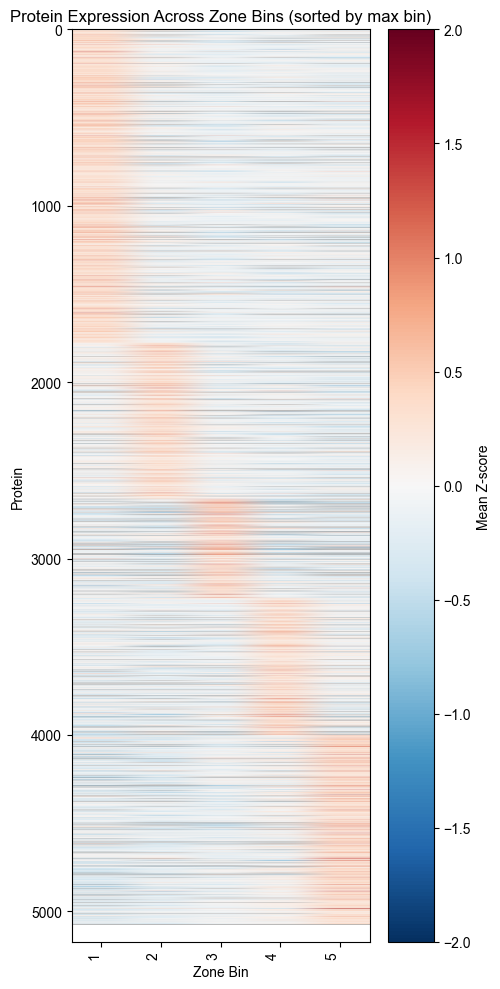

In [ ]:
max_bin = zone_z_means.idxmax(axis=1)  # returns the column (bin) of max value per protein

# Sort proteins first by the bin of max value, then by max value descending
zone_z_means["max_bin"] = max_bin

# Sort by max_bin (ascending) and then max_value (descending)
zone_z_means_sorted = zone_z_means.sort_values(["max_bin"], ascending=True)

# Drop helper columns before plotting
zone_z_means_sorted = zone_z_means_sorted.drop(columns=["max_bin"])

# Plot heatmap
fig, ax = plt.subplots(figsize=(5, 10))
im = ax.imshow(zone_z_means_sorted.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)

ax.set_xlabel("Zone Bin")
ax.set_ylabel("Protein")
ax.set_xticks(range(len(zone_z_means_sorted.columns)))
ax.set_xticklabels(zone_z_means_sorted.columns, rotation=90, ha="right")

plt.colorbar(im, ax=ax, label="Mean Z-score")
plt.title("Protein Expression Across Zone Bins (sorted by max bin)")
plt.tight_layout()
plt.show()

---

# Transcription Factor Activity Inference with Decoupler

## Why Infer TF Activity?

Proteomics measures **protein abundance**, but biological function is often controlled by **transcription factor (TF) activity**. 

**Key insight**: If a TF's target proteins are consistently upregulated, we can infer that TF is more active - even if we don't directly measure the TF itself.

## Decoupler Framework

We use **decoupler** to estimate TF activity from protein abundance:

1. **Prior Knowledge**: TF-target relationships from CollecTRI database
2. **Activity Score**: Statistical measure of target enrichment (ULM method)
3. **Comparison**: Identify TFs with differential activity across zones

## Expected Liver Zonation TFs

| TF | Expected Pattern | Biological Role |
|----|------------------|-----------------|
| **HNF4A** | Periportal | Master liver TF, gluconeogenesis |
| **PPARA** | Periportal | Fatty acid oxidation |
| **SREBF1** | Pericentral | Lipogenesis |
| **TCF7L2** | Pericentral | Wnt signaling (with CTNNB1) |
| **MAF** | Pericentral | Zonation maintenance |

## Important Caveats

- **Protein vs mRNA**: TF-target databases are often defined at mRNA level
- **Coverage**: Limited overlap between detected proteins and known TF targets
- **Post-translational regulation**: TF activity ≠ TF abundance (phosphorylation, localization matter)

Despite these limitations, TF activity inference provides biological insight beyond individual protein changes and can reveal regulatory mechanisms driving zonation patterns.

Import decoupler package:

In [ ]:
# decoupler imports
import decoupler as dc

  from .autonotebook import tqdm as notebook_tqdm



We will log transform - make sure we're working on the right layer. 
We choose the zero version, as ULM doesn't except nan values

In [ ]:
adata_dc = adata_filtered.copy()

adata_dc.X = adata_dc.layers["zero_filled"].copy()
sc.pp.log1p(adata_dc, base=2)

Load the TF-target dataset from the package and check intersection:

In [ ]:
# Get CollecTRI TF-target network
collectri = dc.op.collectri(organism="human")

print(f"CollecTRI network: {len(collectri)} TF-target interactions")
print(f"Number of TFs: {collectri['source'].nunique()}")
print(f"Number of target genes: {collectri['target'].nunique()}")
print("\nNetwork structure:")
display(collectri.head(10))

# Check overlap between our proteins and the TF-target network
our_genes = set(adata_dc.var["single_gene_name"])
network_targets = set(collectri["target"])
overlap = our_genes.intersection(network_targets)

print(f"Genes in our data: {len(our_genes)}")
print(f"Target genes in network: {len(network_targets)}")
print(f"Overlap: {len(overlap)} ({100 * len(overlap) / len(our_genes):.1f}%)")

print(f"number of overlapping proteins is {len(overlap)}, make sure it is sufficient for robust TF activity inference.")


# make unique row indices
adata_dc.var_names = adata_dc.var["single_gene_name"]
print(adata_dc.var_names)

adata_dc.var_names_make_unique()
adata_dc.shape

CollecTRI network: 42990 TF-target interactions
Number of TFs: 1185
Number of target genes: 6675

Network structure:


,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
5,STAT5B,IL2,1.0,ExTRI,10022878,regulon
6,RELA,FAS,1.0,ExTRI;NTNU.Curated;TRRUST,10022897;10871852;11290773;11473033;16317104;1...,PMID
7,WT1,NR0B1,1.0,ExTRI;GEREDB,10022915;12151099,PMID
8,NR0B2,CASP1,1.0,ExTRI,10022928,default activation
9,SP1,ALDOA,1.0,DoRothEA-A;ExTRI;TFactS,10023068;8524331,PMID


AnnData expects .var.index to contain strings, but got values like:
    ['GATD3', 'TRBJ1-3', 'UBA6', 'SHTN1', 'ILVBL']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")

AnnData expects .var.index to contain strings, but got values like:
    ['GATD3', 'TRBJ1-3', 'UBA6', 'SHTN1', 'ILVBL']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")



Genes in our data: 1656
Target genes in network: 6675
Overlap: 840 (50.7%)
number of overlapping proteins is 840, make sure it is sufficient for robust TF activity inference.
CategoricalIndex(['GATD3', 'TRBJ1-3', 'UBA6', 'SHTN1', 'ILVBL', 'ANKRD18B',
                  'FUOM', 'VWA8', 'USP17L1', 'ASPDH',
                  ...
                  'PSAT1', 'SLC25A15', 'ALG5', 'COPG1', 'CLIC4', 'SPCS1',
                  'EMILIN1', 'MTCH2', 'SLCO1B1', 'SQOR'],
                 categories=['A1CF', 'A2M', 'AADAC', 'AADAT', ..., 'YWHAQ', 'YWHAZ', 'ZC3HAV1', 'ZG16B'], ordered=False, dtype='category', name='single_gene_name', length=1656)


(531, 1656)

---

# Run TF Activity Inference

Decoupler provides multiple methods for activity inference:

| Method | Description | Best for |
|--------|-------------|----------|
| **wmean** | Weighted mean of target expression | General use |
| **ulm** | Univariate Linear Model | When directions (act/rep) are reliable |
| **mlm** | Multivariate Linear Model | Accounting for co-regulation |
| **wsum** | Weighted sum | When all targets matter equally |

We'll use `run_ulm` (Univariate Linear Model) as the primary method, which performs a linear regression for each TF.

In [ ]:
# Run Univariate Linear Model (ULM) for TF activity inference
dc.mt.ulm(
    data=adata_dc,
    net=collectri,
    verbose=True,
    raw=False,
)

# Results are stored in adata.obsm
print("\nResults stored in:")
print("  - adata_dc.obsm['ulm_estimate']: TF activity scores")
print("  - adata_dc.obsm['ulm_pvals']: p-values")

INFO:root:ulm - Running ulm
INFO:root:Extracted omics mat with 531 rows (observations) and 1656 columns (features)
INFO:root:Network adjacency matrix has 802 unique features and 214 unique sources
INFO:root:ulm - fitting 214 univariate models of 1656 observations (targets) with 1654 degrees of freedom
INFO:root:ulm - adjusting p-values by FDR
INFO:root:ulm - done



Results stored in:
  - adata_dc.obsm['ulm_estimate']: TF activity scores
  - adata_dc.obsm['ulm_pvals']: p-values


Extract TF activity estimates and show the top 20 active TFs in the hepatocytes and the top 20 variable TFs:

In [ ]:
tf_activities = adata_dc.obsm["score_ulm"]
tf_pvals = adata_dc.obsm["padj_ulm"]

# calculate tf_activities column means
tf_activities_means = tf_activities.mean()
# sort by means
tf_activities_means = tf_activities_means.sort_values(ascending=False)
print("\nTop TFs by mean activity:")
print(tf_activities_means.head(20))

# variance of tf_activities
tf_var = tf_activities.var().sort_values(ascending=False)
print("\nTop TFs by activity variance:")
print(tf_var.head(20))


Top TFs by mean activity:
CEBPB     4.953113
CEBPG     3.854207
CEBPA     3.590686
PPARA     3.583710
SP1       3.357533
DBP       3.033312
KLF11     2.968757
RARB      2.808760
MYC       2.707510
PPARG     2.705729
JUN       2.525194
GATA4     2.515054
HIF1A     2.514218
HNF4A     2.511992
DDIT3     2.495306
SREBF1    2.482112
NFE2L2    2.439815
ESR1      2.428437
NFYB      2.381509
NR3C1     2.356416
dtype: float64

Top TFs by activity variance:
SRSF2     2.107434
SMAD3     2.013538
NCOA3     1.918451
CEBPE     1.880043
MBD2      1.667031
HNF1A     1.482369
NR1I3     1.326112
CREM      1.313287
MAF       1.214274
REL       1.199312
CEBPB     1.196911
PAX6      1.157677
VDR       1.149391
SMAD7     1.141421
NFAT5     1.139039
SP1       1.131627
EP300     1.080585
NKX2-5    1.075080
HNF4G     1.068666
CUX1      1.067786
dtype: float64


---

# Visualize TF Activities


## Compare TF Activities Between Cetral and Portal zones


In [ ]:
# Add condition to activities dataframe
tf_activities_df = tf_activities.copy()
tf_activities_df["zone"] = adata_dc.obs["zone"].to_numpy()

# Calculate mean activity per condition
mean_by_condition = tf_activities_df.groupby("zone").mean()

# Calculate activity difference (AD - Control)
activity_diff = mean_by_condition.loc["zone_1"] - mean_by_condition.loc["zone_5"]
activity_diff = activity_diff.sort_values()

print("TFs more active in zone 1 - central (top 10):")
print(activity_diff.tail(10))
print("\nTFs less active in zone 5 - portal (top 10):")
print(activity_diff.head(10))

TFs more active in zone 1 - central (top 10):
DBP      0.886203
HR       0.886828
USF1     0.903145
NR1H3    0.941595
NR1I2    0.942652
VDR      0.973535
ARNT     1.182978
AHR      1.218691
HNF1A    1.423092
NR1I3    1.426813
dtype: float64

TFs less active in zone 5 - portal (top 10):
MAF     -1.107194
RELA    -0.943795
NCOR2   -0.935433
FOXO1   -0.749511
ETS2    -0.615703
SMAD7   -0.454564
MEF2C   -0.414948
NR4A1   -0.414334
ATF6    -0.359321
CIITA   -0.353438
dtype: float64


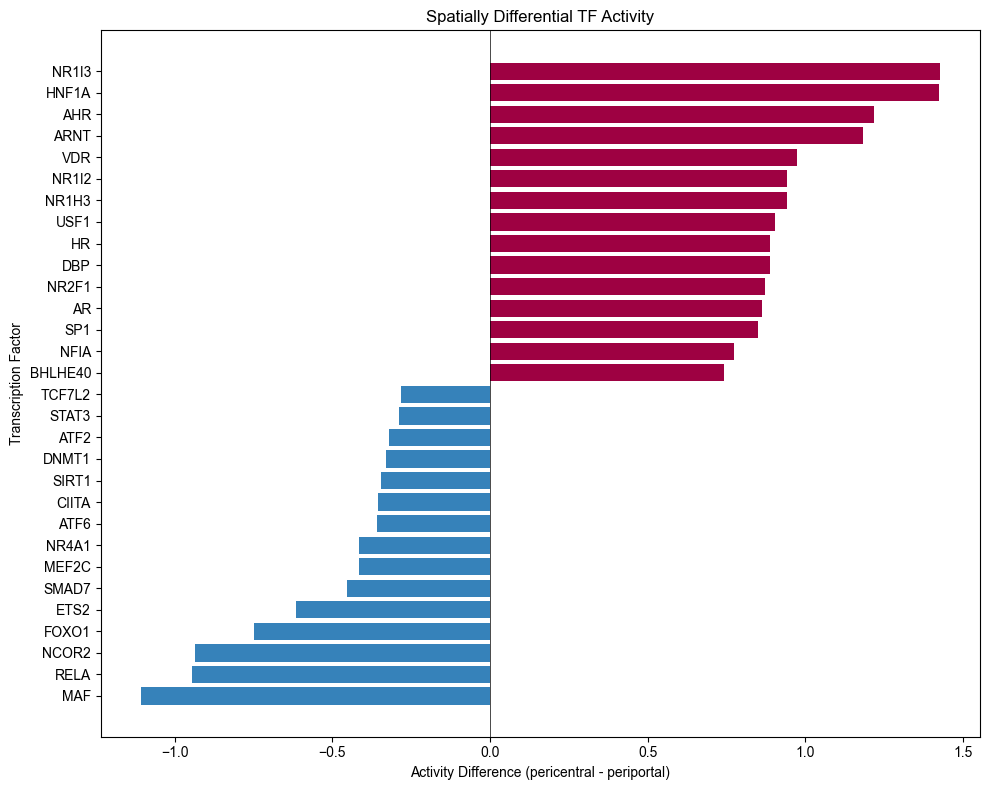

In [ ]:
# Plot top differential TFs
n_top = 15
top_up = activity_diff.tail(n_top)
top_down = activity_diff.head(n_top)
top_diff = pd.concat([top_down, top_up])

fig, ax = plt.subplots(figsize=(10, 8))
colors = [BaseColors.get("blue") if x < 0 else BaseColors.get("red") for x in top_diff.to_numpy()]
ax.barh(range(len(top_diff)), top_diff.to_numpy(), color=colors)
ax.set_yticks(range(len(top_diff)))
ax.set_yticklabels(top_diff.index)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Activity Difference (pericentral - periportal)")
ax.set_ylabel("Transcription Factor")
ax.set_title("Spatially Differential TF Activity")

plt.tight_layout()
plt.show()

The identified highest differential TF NR1I3 was indeed found to induce pericentral functions in the liver (https://www.sciencedirect.com/science/article/pii/S1534580725006653?via%3Dihub). Inversely, the lowest differential TF MAF was found to be associated with silencing the pericentral functions, where MAF deletion resulted in larger pericentral areas (hepatocytes remoted from CV also exressed GS, otherwise exclussively expressed by pericentral hepatocytes: https://www.sciencedirect.com/science/article/pii/S1934590922001096). This anecdotal validation using literature concordance serves as a technical validation rather than biological inference, confirming that our approach recovers expected zonation-associated TFs.

## Violin Plots for Specific TFs

Examine the distribution of activity scores for specific TFs of interest.

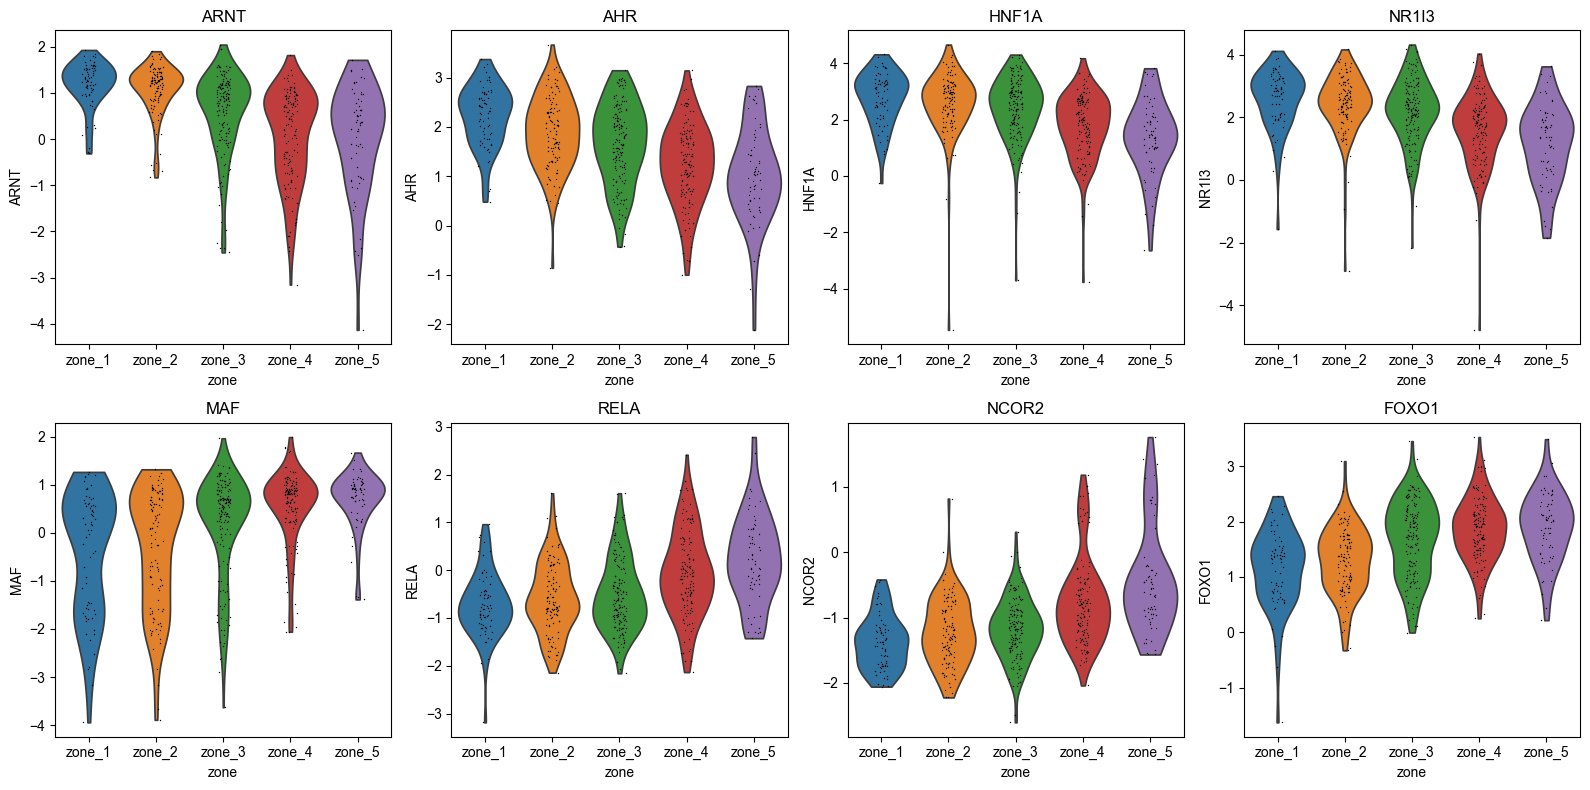

In [ ]:
# Select TFs to visualize
tfs_to_plot = top_diff.tail(4).index.tolist() + top_diff.head(4).index.tolist()
tfs_to_plot = [tf for tf in tfs_to_plot if tf in tf_activities.columns]

if len(tfs_to_plot) > 0:
    # Create AnnData with TF activities for easy plotting with scanpy
    adata_tf = ad.AnnData(
        X=tf_activities.values, obs=adata_dc.obs.copy(), var=pd.DataFrame(index=tf_activities.columns)
    )

    # Plot violin plots
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i, tf in enumerate(tfs_to_plot[:8]):
        if tf in adata_tf.var_names:
            sc.pl.violin(adata_tf, keys=tf, groupby="zone", ax=axes[i], show=False)
            axes[i].set_title(tf)

    for i, tf in enumerate(tfs_to_plot[:8]):
        if tf in adata_dc.var_names:
            sc.pl.violin(adata_dc, keys=tf, groupby="zone", ax=axes[i], show=False)
            axes[i].set_title(tf)

    plt.tight_layout()
    plt.show()

---

# Summary & Key Takeaways

## What We Accomplished

1. **Data Loading**: Imported scDVP proteomics data into AnnData format with alphapepttools
2. **Quality Control**: Assessed sample and protein quality, identified technical vs biological variation
3. **Filtering**: Applied manuscript-based thresholds for samples and proteins
4. **PCA Analysis**: Explored variance structure, confirmed biological signal
5. **Zonation Heatmap**: Recreated Figure 2B showing protein gradients across liver zones
6. **TF Activity**: Inferred transcription factor activity differences between zones

## Key Proteomics Insights

### Things to Watch Out For
- **Missing values are NOT random**: Low-abundance proteins have more missingness
- **Contaminants dominate**: Consider excluding from some analyses
- **Batch effects**: Always check if technical factors drive variance

## Next Steps
- Apply batch correction if needed (ComBat)
- If needed, consider imputation and/or additional normalization, and assess the QC metrics again to see if there is an improvement


